Loading Data

RUN: /usr/bin/python3 -m pip install -q h5py mne optuna scikit-learn pandas
RUN: wget -O /content/my_file https://surfdrive.surf.nl/s/ks6qE3xLm37wmrS/download
RUN: unzip -q /content/my_file -d /content/my_folder
Checking folders
intra_train exists: True | /content/my_folder/Final Project data/Intra/train
intra_test exists: True | /content/my_folder/Final Project data/Intra/test
cross_train exists: True | /content/my_folder/Final Project data/Cross/train
cross_test1 exists: True | /content/my_folder/Final Project data/Cross/test1
cross_test2 exists: True | /content/my_folder/Final Project data/Cross/test2
cross_test3 exists: True | /content/my_folder/Final Project data/Cross/test3
Extracting: /content/my_folder/Final Project data/Intra/train
Number of files: 32
001/032 | label=rest    | subj=105923 | matrix=(248, 35624) | windows=16 | file=rest_105923_1.h5
002/032 | label=rest    | subj=105923 | matrix=(248, 35624) | windows=16 | file=rest_105923_2.h5
003/032 | label=rest    | subj=1059

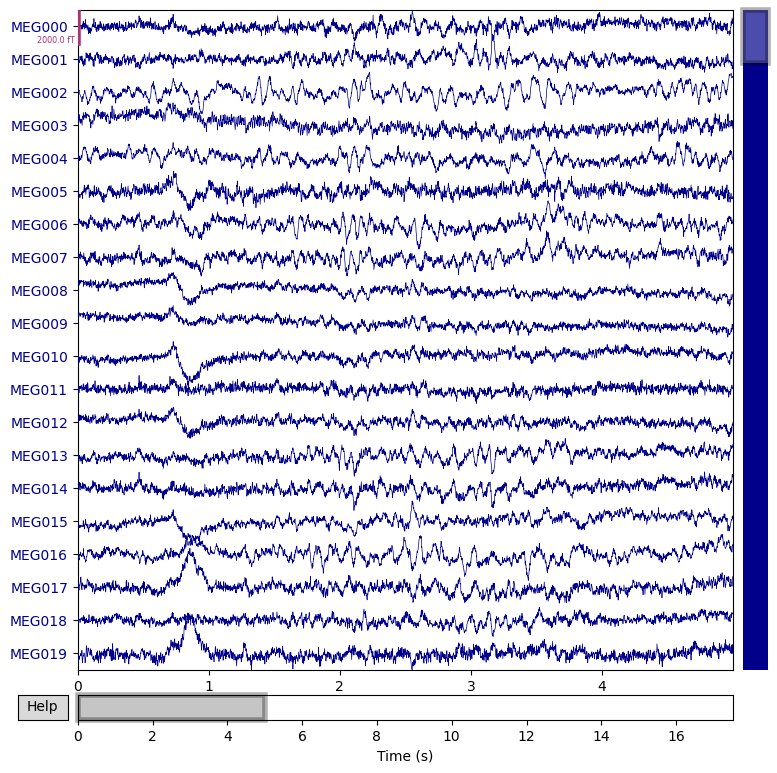

Effective window size : 4.096 (s)
Plotting power spectral density (dB=True).


/tmp/ipykernel_2978/3899451951.py:261: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raws[r].compute_psd().plot()


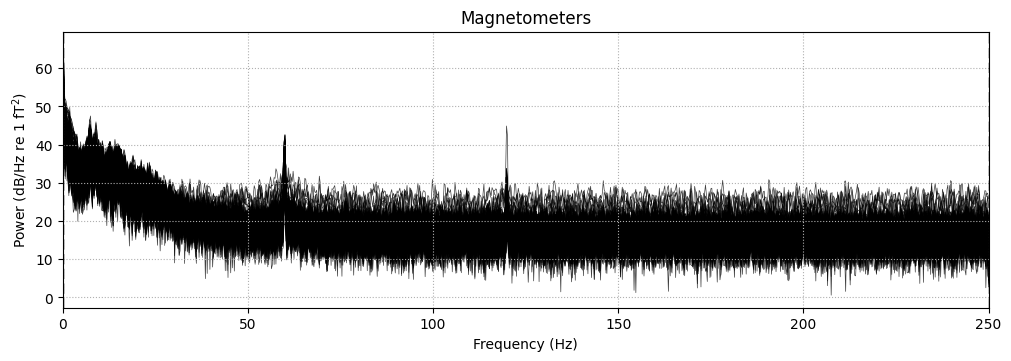

In [ ]:
# CELL 1 DATA PIPELINE # Builds all training/testing variations required for the MEG project. # Main changes with respect to the original:
# 1. Per display Now the SUBJECT ID is tracked not only on a per file group basis.
# This enables Cell 2 to do leave-one-subject-out cross-validation, which is the only valid validation method for the cross configuration, since Cross/train contains only two subjects.
# 2. Download and unzip are protected to avoid re-downloading 4.5 GB. 3. The two redundant occurrences of this pipeline have been merged into one version.
# 4. Scoring per recording is unchanged because it was already topic independent. Cell 2 still has bandpower and feature scaling. For each split, the following are generated: - X_*: float32 array of shape (n_windows, 248, 1000) - y_*: int64 label identifiers - groups_*: int64 identifiers for each recording (file) - subjects_*: int64 subject identifiers extracted from filename The variable experiments[key] contains X_train, y_train, X_test and y_test and the Matching groups_* and subjects_* for training and testing.

Only the standard library.  The third-party imports should go after the installation block below, otherwise a fresh runtime will crash with an error when running `import mne` before it is installed (Colab comes with numpy, h5py, and matplotlib but not mne).
import os
import sys
import subprocess


# Download and install (guarded)


ARCHIVE_PATH = "/content/my_file"
ARCHIVE_URL = "https://surfdrive.surf.nl/s/ks6qE3xLm37wmrS/download"
EXPECTED_SIZE = 4874175804
DATA_ROOT = "/content/my_folder"


def sh(cmd):
    print("RUN:", " ".join(cmd))
    subprocess.run(cmd, check=True)


# Install python deps quietly, BEFORE importing them.
sh([sys.executable, "-m", "pip", "install", "-q",
    "h5py", "mne", "optuna", "scikit-learn", "pandas"])

# Third party imports, now that the packages are installed.
import h5py
import numpy as np
import mne
import matplotlib.pyplot as plt

# Download only if the archive is missing or the wrong size.
need_download = (
    not os.path.exists(ARCHIVE_PATH)
    or os.path.getsize(ARCHIVE_PATH) != EXPECTED_SIZE
)
if need_download:
    sh(["wget", "-O", ARCHIVE_PATH, ARCHIVE_URL])
else:
    print("Archive already present, skipping download.")

# Unzip only if the data folder is not already there.
if not os.path.isdir(DATA_ROOT):
    sh(["unzip", "-q", ARCHIVE_PATH, "-d", DATA_ROOT])
else:
    print("Data folder already present, skipping unzip.")

# Label dictionaries
l2i = {"rest": 0, "motor": 1, "math": 2, "memory": 3}
i2l = {0: "rest", 1: "motor", 2: "math", 3: "memory"}

# Path configuration
BASE_DIR = f"{DATA_ROOT}/Final Project data"

paths = {
    "intra_train": f"{BASE_DIR}/Intra/train",
    "intra_test":  f"{BASE_DIR}/Intra/test",
    "cross_train": f"{BASE_DIR}/Cross/train",
    "cross_test1": f"{BASE_DIR}/Cross/test1",
    "cross_test2": f"{BASE_DIR}/Cross/test2",
    "cross_test3": f"{BASE_DIR}/Cross/test3",
}

# Helper functions
# rest_113922_1.h5             ->  rest_113922
# task_story_math_113922_1.h5  ->  task_story_math_113922
# drop the trailing chunk index
def get_dataset_name(file_name_with_dir):

    filename = file_name_with_dir.split("/")[-1].replace(".h5", "")
    parts = filename.split("_")[:-1]
    return "_".join(parts)

# The subject id is the final numeric token of the dataset name.
# rest_113922 -> 113922 ; task_story_math_113922 -> 113922
def get_subject_id(dataset_name):

    return int(dataset_name.split("_")[-1])


def get_filename_paths(path, verbose=False):
    files = sorted(f for f in os.listdir(path) if f.endswith(".h5"))
    filepaths = [f"{path}/{f}" for f in files]
    if verbose:
        print("Folder:", path)
        print("Number of files:", len(filepaths))
        print("\n".join(filepaths))
    return filepaths


def get_task_label_from_dataset_name(dataset_name):
    parts = dataset_name.split("_")
    if dataset_name.startswith("rest"):
        return "rest"
    if "motor" in parts:
        return "motor"
    if "math" in parts:
        return "math"
    if "memory" in parts:
        return "memory"
    raise ValueError(f"Could not infer label from dataset name: {dataset_name}")

# Per recording, per channel z scoring. This is subject agnostic
# because each recording is standardized by its own statistics.
def preprocess(matrix, target_sfreq=500, orig_sfreq=2034):

    info = mne.create_info(
        ch_names=[f"MEG{i:03d}" for i in range(matrix.shape[0])],
        sfreq=orig_sfreq,
        ch_types=["mag"] * matrix.shape[0],
    )
    raw = mne.io.RawArray(matrix, info, verbose=False)
    raw.resample(target_sfreq, verbose=False)

    data = raw.get_data()
    mean = data.mean(axis=1, keepdims=True)
    std = data.std(axis=1, keepdims=True)
    normalized = ((data - mean) / (std + 1e-8)).astype(np.float32)
    return normalized, raw


def window_recording(arr, win_len, stride):
    n_channels, n_time = arr.shape
    if n_time < win_len:
        return np.empty((0, n_channels, win_len), dtype=arr.dtype)
    n_windows = (n_time - win_len) // stride + 1
    out = np.empty((n_windows, n_channels, win_len), dtype=arr.dtype)
    for i in range(n_windows):
        start = i * stride
        out[i] = arr[:, start:start + win_len]
    return out
# per recording (file) id
# per subject id
def extract_and_preprocess_data(
    path,
    l2i,
    target_sfreq=500,
    window_sec=2.0,
    overlap=0.5,
    keep_raws_first_n=1,
):
    win_len = int(window_sec * target_sfreq)
    stride = max(1, int(win_len * (1.0 - overlap)))

    data_chunks = []
    labels = []
    groups = []

    subjects = []
    raws = []
    metadata = []

    filepaths = get_filename_paths(path)

    print("=" * 80)
    print("Extracting:", path)
    print("Number of files:", len(filepaths))
    print("=" * 80)

    for file_idx, file_path in enumerate(filepaths):
        with h5py.File(file_path, "r") as f:
            dataset_name = get_dataset_name(file_path)
            label = get_task_label_from_dataset_name(dataset_name)
            label_id = l2i[label]
            subject_id = get_subject_id(dataset_name)

            matrix = f.get(dataset_name)[()]
            preprocessed, raw = preprocess(matrix, target_sfreq=target_sfreq)
            windows = window_recording(preprocessed, win_len=win_len, stride=stride)

            n = windows.shape[0]
            data_chunks.append(windows)


            labels.extend([label_id] * n)
            groups.extend([file_idx] * n)
            subjects.extend([subject_id] * n)

            metadata.append({
                "file_path": file_path,
                "dataset_name": dataset_name,
                "label": label,
                "label_id": label_id,
                "subject_id": subject_id,
                "matrix_shape": matrix.shape,
                "windows": n,
            })

            if file_idx < keep_raws_first_n:
                raws.append(raw)

            print(
                f"{file_idx + 1:03d}/{len(filepaths):03d} | "
                f"label={label:7s} | subj={subject_id} | "
                f"matrix={matrix.shape} | windows={n} | "
                f"file={os.path.basename(file_path)}"
            )

    if len(data_chunks) > 0:
        X = np.concatenate(data_chunks, axis=0).astype(np.float32)
    else:
        X = np.empty((0,), dtype=np.float32)

    y = np.asarray(labels, dtype=np.int64)
    groups = np.asarray(groups, dtype=np.int64)


    subjects = np.asarray(subjects, dtype=np.int64)

    print("=" * 80)
    print("Final X shape:", X.shape)
    print("Final y shape:", y.shape)
    if len(y) > 0:
        unique, counts = np.unique(y, return_counts=True)
        print("Class counts:")
        for cls, count in zip(unique, counts):
            print(f"  {i2l[int(cls)]}: {int(count)}")
        print("Subjects:", sorted(set(int(s) for s in subjects)))
    print("=" * 80)

    return X, y, groups, subjects, raws, metadata


def plot_data(raws, n, labels, i2l):
    if not isinstance(raws, list):
        raws = [raws]
    if isinstance(labels, np.ndarray):
        labels = labels.tolist()
    if not isinstance(labels, list):


        labels = [labels]
    for r in range(min(n, len(raws))):
        print(f"{'#' * 20} PLOT FOR {i2l[int(labels[r])]} {'#' * 20}")
        raws[r].plot(duration=5, n_channels=20)
        raws[r].compute_psd().plot()
        plt.show()
    print("=" * 100)


# Folder existence check


print("=" * 80)
print("Checking folders")
print("=" * 80)
for name, path in paths.items():
    print(name, "exists:", os.path.exists(path), "|", path)

# Extract all required datasets


TARGET_SFREQ = 500
WINDOW_SEC = 2.0
OVERLAP = 0.5


def extract(split):
    return extract_and_preprocess_data(
        paths[split], l2i,
        target_sfreq=TARGET_SFREQ, window_sec=WINDOW_SEC,
        overlap=OVERLAP, keep_raws_first_n=1,
    )


(X_intra_train, y_intra_train, groups_intra_train,
 subjects_intra_train, raws_intra_train, meta_intra_train) = extract("intra_train")

(X_intra_test, y_intra_test, groups_intra_test,

 subjects_intra_test, raws_intra_test, meta_intra_test) = extract("intra_test")

(X_cross_train, y_cross_train, groups_cross_train,
 subjects_cross_train, raws_cross_train, meta_cross_train) = extract("cross_train")


(X_cross_test1, y_cross_test1, groups_cross_test1,
 subjects_cross_test1, raws_cross_test1, meta_cross_test1) = extract("cross_test1")

(X_cross_test2, y_cross_test2, groups_cross_test2,

 subjects_cross_test2, raws_cross_test2, meta_cross_test2) = extract("cross_test2")

(X_cross_test3, y_cross_test3, groups_cross_test3,
 subjects_cross_test3, raws_cross_test3, meta_cross_test3) = extract("cross_test3")




# Combined cross test set. File groups are offset so recordings stay unique across the three sets. Subject ids are globally unique already, so they need no offset.
X_cross_all_test = np.concatenate([X_cross_test1, X_cross_test2, X_cross_test3], axis=0)

y_cross_all_test = np.concatenate([y_cross_test1, y_cross_test2, y_cross_test3], axis=0)
groups_cross_all_test = np.concatenate(
    [groups_cross_test1, groups_cross_test2 + 1000, groups_cross_test3 + 2000], axis=0
)
subjects_cross_all_test = np.concatenate(
    [subjects_cross_test1, subjects_cross_test2, subjects_cross_test3], axis=0
)


# Experiment dictionary


experiments = {
    "intra": {
        "name": "Intra subject",
        "train_folder": "Intra/train",
        "test_folder": "Intra/test",
        "X_train": X_intra_train, "y_train": y_intra_train,


        "X_test": X_intra_test, "y_test": y_intra_test,
        "groups_train": groups_intra_train, "groups_test": groups_intra_test,
        "subjects_train": subjects_intra_train, "subjects_test": subjects_intra_test,
    },
    "cross_test1": {
        "name": "Cross subject test1",
        "train_folder": "Cross/train",
        "test_folder": "Cross/test1",
        "X_train": X_cross_train, "y_train": y_cross_train,
        "X_test": X_cross_test1, "y_test": y_cross_test1,
        "groups_train": groups_cross_train, "groups_test": groups_cross_test1,
        "subjects_train": subjects_cross_train, "subjects_test": subjects_cross_test1,
    },
    "cross_test2": {
        "name": "Cross subject test2",
        "train_folder": "Cross/train",
        "test_folder": "Cross/test2",
        "X_train": X_cross_train, "y_train": y_cross_train,
        "X_test": X_cross_test2, "y_test": y_cross_test2,
        "groups_train": groups_cross_train, "groups_test": groups_cross_test2,
        "subjects_train": subjects_cross_train, "subjects_test": subjects_cross_test2,
    },
    "cross_test3": {
        "name": "Cross subject test3",
        "train_folder": "Cross/train",



        "test_folder": "Cross/test3",
        "X_train": X_cross_train, "y_train": y_cross_train,
        "X_test": X_cross_test3, "y_test": y_cross_test3,
        "groups_train": groups_cross_train, "groups_test": groups_cross_test3,
        "subjects_train": subjects_cross_train, "subjects_test": subjects_cross_test3,
    },
    "cross_all": {
        "name": "Cross subject all tests combined",
        "train_folder": "Cross/train",


        "test_folder": "Cross/test1 + Cross/test2 + Cross/test3",
        "X_train": X_cross_train, "y_train": y_cross_train,
        "X_test": X_cross_all_test, "y_test": y_cross_all_test,
        "groups_train": groups_cross_train, "groups_test": groups_cross_all_test,
        "subjects_train": subjects_cross_train, "subjects_test": subjects_cross_all_test,
    },
}

# Summary
print("\n" + "=" * 80)
print("FINAL REQUIRED TRAIN/TEST VARIATIONS")
print("=" * 80)
for key, exp in experiments.items():
    train_subj = sorted(set(int(s) for s in exp["subjects_train"]))
    test_subj = sorted(set(int(s) for s in exp["subjects_test"]))
    print("\nExperiment key:", key)
    print("Name:", exp["name"])


    print("X_train:", exp["X_train"].shape, "| X_test:", exp["X_test"].shape)
    print("Train subjects:", train_subj)

    print("Test subjects: ", test_subj)
    print("Number of distinct training subjects:", len(train_subj))

print("\n" + "=" * 80)
print("CROSS NOTE")
print("=" * 80)
print(
    "Cross/train has only two subjects, so subject held out CV means two\n"
    "folds (leave one subject out), not five. In Cell 2, pass\n"
    "subjects_train as the grouping array and use LeaveOneGroupOut."
)



if len(raws_intra_train) > 0:
    plot_data(raws_intra_train, 1, y_intra_train, i2l)

In [ ]:

# Optuna tuning -> best params -> full CV

import time
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

try:
    import optuna
except ImportError as e:
    raise ImportError(
        "Optuna is not installed. Run this first in a notebook cell:\n"
        "!pip install optuna"
    ) from e


# 0. Global config


SEED = 42

TARGET_SFREQ = 500
N_CLASSES = len(l2i)

# Optuna
N_TRIALS = 30
OPTUNA_EPOCHS = 15
OPTUNA_VAL_SIZE = 0.20

# Final CV
N_SPLITS = 5
MAX_EPOCHS = 50

# General
BATCH_SIZE_DEFAULT = 32
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BANDS = [
    ("delta", 1.0, 4.0),
    ("theta", 4.0, 8.0),
    ("alpha", 8.0, 13.0),
    ("beta", 13.0, 30.0),
    ("low_gamma", 30.0, 80.0),
]


def seed_all(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_all(SEED)

print("FULL PIPELINE: Optuna -> best params -> CV")
print("Device:", DEVICE)
print("Input data shape:", data.shape)
print("Labels shape:", labels.shape)



# 1. Shape handling


def ensure_samples_channels_time(X):

    X = np.asarray(X, dtype=np.float32)

    if X.ndim == 4 and X.shape[-1] == 1:
        X = X[..., 0]

    if X.ndim != 3:
        raise ValueError(f"Expected X shape (samples, channels, time), got {X.shape}")

    if X.shape[2] < X.shape[1]:
        X = np.transpose(X, (0, 2, 1))

    return X.astype(np.float32)


X_all = ensure_samples_channels_time(data)
y_all = np.asarray(labels, dtype=np.int64)

print("Standardized X shape:", X_all.shape)


# 2. Bandpower map preprocessor


class BandpowerMapPreprocessor:


    def __init__(self, sfreq=500, bands=None, eps=1e-8):
        self.sfreq = float(sfreq)
        self.bands = bands if bands is not None else BANDS
        self.eps = eps
        self.scaler = None

    def _bandpower(self, X):
        X = ensure_samples_channels_time(X)
        n_samples, n_channels, n_time = X.shape

        freqs = np.fft.rfftfreq(n_time, d=1.0 / self.sfreq)



        fft = np.fft.rfft(X, axis=-1)
        power = (np.abs(fft) ** 2) / max(n_time, 1)

        out = []

        for name, low, high in self.bands:
            mask = (freqs >= low) & (freqs < high)

            if not np.any(mask):
                bp = np.zeros((n_samples, n_channels), dtype=np.float32)
            else:
                bp = power[:, :, mask].mean(axis=-1)


            bp = np.log1p(bp + self.eps).astype(np.float32)
            out.append(bp)

        return np.stack(out, axis=1).astype(np.float32)  # (N, bands, channels)

    def fit(self, X):
        Z = self._bandpower(X)
        flat = Z.reshape(Z.shape[0], -1)
        self.scaler = StandardScaler().fit(flat)
        return self

    def transform(self, X):
        if self.scaler is None:
            raise RuntimeError("Call fit before transform.")

        Z = self._bandpower(X)

        flat = Z.reshape(Z.shape[0], -1)
        flat = self.scaler.transform(flat).astype(np.float32)
        Z = flat.reshape(Z.shape[0], len(self.bands), -1)

        return Z[:, np.newaxis, :, :].astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

    def band_names(self):
        return [b[0] for b in self.bands]


# 3. PCA bandpower preprocessor


class PCABandpowerMapPreprocessor:


    def __init__(
        self,
        sfreq=500,
        bands=None,

        n_components=32,
        whiten=False,
        random_state=42,
        eps=1e-8,
    ):
        self.sfreq = float(sfreq)
        self.bands = bands if bands is not None else BANDS
        self.n_components = int(n_components)
        self.whiten = bool(whiten)
        self.random_state = int(random_state)
        self.eps = eps

        self.bandpower_preprocessor = BandpowerMapPreprocessor(
            sfreq=sfreq,
            bands=bands,
            eps=eps,
        )

        self.pca_models = None

        self.scaler = None
        self.actual_components = None

    def fit(self, X):
        # Get unstandardized bandpower directly.
        # (N, bands, components)
        Z = self.bandpower_preprocessor._bandpower(X)

        n_samples, n_bands, n_channels = Z.shape
        self.actual_components = min(self.n_components, n_channels, max(1, n_samples - 1))

        transformed = []


        pca_models = []

        for band_idx in range(n_bands):
            pca = PCA(
                n_components=self.actual_components,
                whiten=self.whiten,
                random_state=self.random_state,
            )

            z = pca.fit_transform(Z[:, band_idx, :])
            transformed.append(z.astype(np.float32))
            pca_models.append(pca)

        P = np.stack(transformed, axis=1)



        flat = P.reshape(P.shape[0], -1)
        self.scaler = StandardScaler().fit(flat)

        self.pca_models = pca_models


        return self

    def transform(self, X):
        if self.pca_models is None or self.scaler is None:
            raise RuntimeError("Call fit before transform.")

        Z = self.bandpower_preprocessor._bandpower(X)

        transformed = []

        for band_idx, pca in enumerate(self.pca_models):
            z = pca.transform(Z[:, band_idx, :])

            transformed.append(z.astype(np.float32))

        P = np.stack(transformed, axis=1)

        flat = P.reshape(P.shape[0], -1)
        flat = self.scaler.transform(flat).astype(np.float32)

        P = flat.reshape(P.shape[0], len(self.bands), -1)
        return P[:, np.newaxis, :, :].astype(np.float32)

    def fit_transform(self, X):
        return self.fit(X).transform(X)


# 4. HSMM-like unsupervised zone features. HSMM-like unsupervised zone labeler. This does not use task labels. It must be fit only on training data. Input: X: (samples, channels, time) Output: hsmm_map: (samples, n_states + 2, bands, spatial_width) The HSMM summary features are broadcast across the band x spatial map. Features: n_states occupancy channels 1 transition-rate channel 1 dominant-state-confidence channel


class HSMMZoneFeatureExtractor:


    def __init__(
        self,
        sfreq=500,
        bands=None,
        zone_sec=0.20,
        n_states=6,
        random_state=42,
        eps=1e-8,
    ):
        self.sfreq = float(sfreq)
        self.bands = bands if bands is not None else BANDS
        self.zone_sec = float(zone_sec)
        self.n_states = int(n_states)
        self.random_state = int(random_state)
        self.eps = float(eps)

        self.zone_len = max(1, int(self.zone_sec * self.sfreq))

        self.kmeans = None
        self.scaler = None
        self.n_channels = None
        self.n_zones = None

    def _zone_bandpower(self, X):
        X = ensure_samples_channels_time(X)

        n_samples, n_channels, n_time = X.shape
        self.n_channels = n_channels

        n_zones = n_time // self.zone_len

        if n_zones < 1:
            raise ValueError(
                f"Window length {n_time} is shorter than one zone length {self.zone_len}."
            )

        self.n_zones = n_zones

        X = X[:, :, : n_zones * self.zone_len]
        Xz = X.reshape(n_samples, n_channels, n_zones, self.zone_len)
        Xz = np.transpose(Xz, (0, 2, 1, 3))

        freqs = np.fft.rfftfreq(self.zone_len, d=1.0 / self.sfreq)


        fft = np.fft.rfft(Xz, axis=-1)
        power = (np.abs(fft) ** 2) / max(self.zone_len, 1)

        out = []

        for name, low, high in self.bands:
            mask = (freqs >= low) & (freqs < high)

            if not np.any(mask):
                bp = np.zeros((n_samples, n_zones, n_channels), dtype=np.float32)
            else:
                bp = power[:, :, :, mask].mean(axis=-1)

            bp = np.log1p(bp + self.eps).astype(np.float32)
            out.append(bp)



          # (N, zones, bands, channels)
        return np.stack(out, axis=2).astype(np.float32)

    def fit(self, X):
        Z = self._zone_bandpower(X)
        n, z, b, c = Z.shape

        flat = Z.reshape(n * z, b * c)

        self.scaler = StandardScaler().fit(flat)
        flat_scaled = self.scaler.transform(flat).astype(np.float32)

        self.kmeans = KMeans(
            n_clusters=self.n_states,

            random_state=self.random_state,
            n_init=10,
        ).fit(flat_scaled)

        return self

    def transform(self, X, output_width):
        if self.kmeans is None or self.scaler is None:
            raise RuntimeError("Call fit before transform.")

        Z = self._zone_bandpower(X)
        n, z, b, c = Z.shape

        flat = Z.reshape(n * z, b * c)
        flat_scaled = self.scaler.transform(flat).astype(np.float32)
        states = self.kmeans.predict(flat_scaled).reshape(n, z)

        occupancy = np.zeros((n, self.n_states), dtype=np.float32)

        for i in range(n):
            counts = np.bincount(states[i], minlength=self.n_states).astype(np.float32)
            occupancy[i] = counts / max(1.0, counts.sum())

        transition_rate = np.zeros((n, 1), dtype=np.float32)

        for i in range(n):
            if z <= 1:
                transition_rate[i, 0] = 0.0

            else:
                transition_rate[i, 0] = np.mean(states[i, 1:] != states[i, :-1])

        dominant_conf = occupancy.max(axis=1, keepdims=True).astype(np.float32)

        summary = np.concatenate(
            [occupancy, transition_rate, dominant_conf],
            axis=1,
        ).astype(np.float32)

        hsmm_map = summary[:, :, np.newaxis, np.newaxis]
        hsmm_map = np.repeat(hsmm_map, repeats=len(self.bands), axis=2)
        hsmm_map = np.repeat(hsmm_map, repeats=output_width, axis=3)

        return hsmm_map.astype(np.float32), states


# 5. Feature builder Fits preprocessing only on X_train_raw, then transforms train/val. Params include:use_pca pca_components pca_whiten use_hsmm hsmm_n_states hsmm_zone_sec
def build_features_for_split(
    X_train_raw,
    X_val_raw,
    params,
    fold_seed=SEED,
    verbose=True,
):


    use_pca = bool(params["use_pca"])

    if use_pca:
        preprocessor = PCABandpowerMapPreprocessor(
            sfreq=TARGET_SFREQ,
            bands=BANDS,
            n_components=int(params["pca_components"]),
            whiten=bool(params["pca_whiten"]),
            random_state=fold_seed,
        )
    else:
        preprocessor = BandpowerMapPreprocessor(
            sfreq=TARGET_SFREQ,
            bands=BANDS,
        )

    preprocessor.fit(X_train_raw)

    X_train_map = preprocessor.transform(X_train_raw)



    X_val_map = preprocessor.transform(X_val_raw)

    if X_train_map.std() == 0:
        raise RuntimeError("X_train_map is all zeros. Preprocessing failed.")

    if bool(params["use_hsmm"]):
        hsmm = HSMMZoneFeatureExtractor(
            sfreq=TARGET_SFREQ,
            bands=BANDS,
            zone_sec=float(params["hsmm_zone_sec"]),
            n_states=int(params["hsmm_n_states"]),
            random_state=fold_seed,
        )

        hsmm.fit(X_train_raw)

        output_width = X_train_map.shape[-1]

        X_train_hsmm, train_states = hsmm.transform(X_train_raw, output_width=output_width)


        X_val_hsmm, val_states = hsmm.transform(X_val_raw, output_width=output_width)

        X_train_map = np.concatenate([X_train_map, X_train_hsmm], axis=1).astype(np.float32)
        X_val_map = np.concatenate([X_val_map, X_val_hsmm], axis=1).astype(np.float32)

        if verbose:

            print("HSMM train states shape:", train_states.shape)
            print("HSMM val states shape:", val_states.shape)

            print(
                "HSMM train state counts:",
                np.bincount(train_states.reshape(-1), minlength=int(params["hsmm_n_states"])),
            )

    if verbose:
        print("X_train_map shape:", X_train_map.shape)
        print("X_val_map shape:", X_val_map.shape)


        print("X_train_map mean/std:", float(X_train_map.mean()), float(X_train_map.std()))

        print("X_val_map mean/std:", float(X_val_map.mean()), float(X_val_map.std()))

    return X_train_map, X_val_map, preprocessor



#6. Model (Standard CNN over spatial maps x band . Input: (batch, bands, width, input_channels) No global average pool. Flattening maintains the exact position of band/channel or band/PCA-component.


class StandardBandpowerCNN(nn.Module):


    def __init__(self, n_classes, input_shape, c1=16, c2=32, dropout=0.25):
        super().__init__()

        in_channels = int(input_shape[0])

        self.conv1 = nn.Conv2d(in_channels, c1, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)

        self.skip = nn.Conv2d(c1, c2, kernel_size=1, bias=False)


        self.dropout = nn.Dropout(dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            h = self._features(dummy)
            flat_dim = h.flatten(1).shape[1]

        self.head = nn.Linear(flat_dim, n_classes)

    def _features(self, x):
        h1 = F.relu(self.bn1(self.conv1(x)))
        h2 = self.bn2(self.conv2(h1)) + self.skip(h1)

        h2 = F.relu(h2)
        return h2

    def forward(self, x):
        h = self._features(x)
        h = h.flatten(1)
        h = self.dropout(h)

        return self.head(h)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



# 7. Training utilities


def make_class_weights(y, n_classes):
    present = np.unique(y)


    weights = compute_class_weight(

        class_weight="balanced",
        classes=present,
        y=y,
    )

    class_weight = np.ones(n_classes, dtype=np.float32)

    for c, w in zip(present, weights):
        class_weight[int(c)] = float(w)

    return torch.tensor(class_weight, dtype=torch.float32)


def make_loaders(X_train, y_train, X_val, y_val, batch_size):
    train_ds = TensorDataset(
        torch.from_numpy(X_train.astype(np.float32)),
        torch.from_numpy(y_train.astype(np.int64)),
    )

    val_ds = TensorDataset(

        torch.from_numpy(X_val.astype(np.float32)),
        torch.from_numpy(y_val.astype(np.int64)),
    )

    train_loader = DataLoader(
        train_ds,

        batch_size=batch_size,
        shuffle=True,
        drop_last=False,
    )

    val_loader = DataLoader(
        val_ds,

        batch_size=batch_size,

        shuffle=False,
        drop_last=False,
    )

    return train_loader, val_loader


@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()

    y_true = []
    y_pred = []
    total_loss = 0.0

    total_n = 0

    if criterion is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")

    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)

        logits = model(xb)
        loss = criterion(logits, yb)

        total_loss += float(loss.item())

        total_n += int(yb.numel())

        y_true.extend(yb.cpu().numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())

    acc = accuracy_score(y_true, y_pred)

    #print(acc)
    avg_loss = total_loss / total_n

    return avg_loss, acc, np.asarray(y_true), np.asarray(y_pred)


def train_model(
    model,
    train_loader,
    val_loader,
    class_weights,
    max_epochs,
    lr,
    weight_decay,
    fold_id=None,
    trial_id=None,
    verbose=True,
):
    model = model.to(DEVICE)
    class_weights = class_weights.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)

    eval_criterion = nn.CrossEntropyLoss(reduction="sum")

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,

        mode="max",
        factor=0.5,
        patience=4,
    )

    best_state = None

    best_val_acc = -1.0
    best_epoch = -1

    history = []

    for epoch in range(1, max_epochs + 1):
        start = time.time()

        model.train()

        total_loss = 0.0
        correct = 0
        total_n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)

            optimizer.zero_grad()

            logits = model(xb)
            loss = criterion(logits, yb)


            loss.backward()
            optimizer.step()

            total_loss += float(loss.detach().item()) * int(yb.numel())
            correct += int((logits.argmax(dim=1) == yb).sum().item())
            total_n += int(yb.numel())

        train_loss = total_loss / total_n


        train_acc = correct / total_n
        #print( train_acc)

        val_loss, val_acc, _, _ = evaluate_model(
            model,
            val_loader,
            criterion=eval_criterion,
        )

        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        row = {
            "fold": fold_id,
            "trial": trial_id,
            "epoch": epoch,
            "train_loss": train_loss,

            "train_acc": train_acc,

            "val_loss": val_loss,


            "val_acc": val_acc,
            "lr": optimizer.param_groups[0]["lr"],
            "time_sec": time.time() - start,
        }

        history.append(row)

        if verbose:
            prefix = ""
            if trial_id is not None:
                prefix += f"trial={trial_id} "
            if fold_id is not None:
                prefix += f"fold={fold_id} "

            print(
                f"{prefix}epoch={epoch:03d} "
                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "


                f"best={best_val_acc:.4f}@{best_epoch} "
                f"lr={optimizer.param_groups[0]['lr']:.2e} "
                f"time={row['time_sec']:.1f}s"
            )

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc, best_epoch


#Optuna objective

# If PCA is off, these do not matter. Still stored for reproducibility.
# If HSMM is off, HSMM parameters do not matter.
def suggest_params(trial):

    use_pca = trial.suggest_categorical("use_pca", [False, True])
    use_hsmm = trial.suggest_categorical("use_hsmm", [False, True])

    params = {
        "use_pca": use_pca,
        "pca_components": trial.suggest_categorical("pca_components", [16, 32, 64, 96]),
        "pca_whiten": trial.suggest_categorical("pca_whiten", [False, True]),


        "use_hsmm": use_hsmm,
        "hsmm_n_states": trial.suggest_categorical("hsmm_n_states", [3, 4, 6, 8]),
        "hsmm_zone_sec": trial.suggest_categorical("hsmm_zone_sec", [0.10, 0.20, 0.25, 0.50]),
        "c1": trial.suggest_categorical("c1", [8, 16, 24, 32]),
        "c2": trial.suggest_categorical("c2", [16, 32, 48, 64]),


        "dropout": trial.suggest_float("dropout", 0.05, 0.50),
        "batch_size": trial.suggest_categorical("batch_size", [16, 32, 64]),
        "lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True),
    }
    #print(params)



    return params


def optuna_objective(trial):
    seed_all(SEED + trial.number)

    params = suggest_params(trial)

    idx = np.arange(len(y_all))

    train_idx, val_idx = train_test_split(
        idx,
        test_size=OPTUNA_VAL_SIZE,
        random_state=SEED + trial.number,
        stratify=y_all,
    )

    X_raw_train = X_all[train_idx]



    X_raw_val = X_all[val_idx]

    y_train = y_all[train_idx]
    y_val = y_all[val_idx]

    try:
        X_train_map, X_val_map, _ = build_features_for_split(
            X_raw_train,
            X_raw_val,
            params,
            fold_seed=SEED + trial.number,
            verbose=False,
        )

        input_shape = X_train_map.shape[1:]

        model = StandardBandpowerCNN(
            n_classes=N_CLASSES,
            input_shape=input_shape,
            c1=int(params["c1"]),
            c2=int(params["c2"]),
            dropout=float(params["dropout"]),
        )

        class_weights = make_class_weights(y_train, N_CLASSES)

        train_loader, val_loader = make_loaders(
            X_train_map,
            y_train,

            X_val_map,
            y_val,
            batch_size=int(params["batch_size"]),
        )

        model, history, best_val_acc, best_epoch = train_model(
            model,
            train_loader,
            val_loader,


            class_weights,
            max_epochs=OPTUNA_EPOCHS,


            lr=float(params["lr"]),


            weight_decay=float(params["weight_decay"]),
            fold_id=None,
            trial_id=trial.number,
            verbose=False,
        )

        trial.set_user_attr("best_epoch", int(best_epoch))





        trial.set_user_attr("params_count", int(count_params(model)))
        trial.set_user_attr("input_shape", tuple(input_shape))

        return float(best_val_acc)

    except Exception as e:
        trial.set_user_attr("failed_reason", repr(e))
        return 0.0

# 9. Run Optuna

print("RUNNING OPTUNA")
print("=" * 80)
print("N_TRIALS:", N_TRIALS)
print("OPTUNA_EPOCHS:", OPTUNA_EPOCHS)

sampler = optuna.samplers.TPESampler(seed=SEED)

study = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="standard_bandpower_cnn_optuna",
)

study.optimize(
    optuna_objective,

    n_trials=N_TRIALS,
    show_progress_bar=True,
)


print("OPTUNA BEST RESULT")
print("=" * 80)

print("Best value:", study.best_value)
print("Best params:")



for k, v in study.best_params.items():
    print(f"  {k}: {v}")

trials_df = study.trials_dataframe()
trials_df.to_csv("standard_bandpower_cnn_optuna_trials.csv", index=False)
print("Saved: standard_bandpower_cnn_optuna_trials.csv")

best_params = dict(study.best_params)

# Ensure keys exist even when some parameters are irrelevant.
for key, default in {
    "use_pca": False,
    "pca_components": 32,
    "pca_whiten": False,


    "use_hsmm": False,
    "hsmm_n_states": 6,
    "hsmm_zone_sec": 0.20,
    "c1": 16,
    "c2": 32,
    "dropout": 0.25,
    "batch_size": 32,
    "lr": 1e-3,
    "weight_decay": 1e-4,
}.items():
    best_params.setdefault(key, default)



# 10. Full CV with best params


print("RUNNING FULL CV WITH BEST PARAMS")
print("=" * 88)

print("Best params used for CV:")
for k, v in best_params.items():
    print(f"  {k}: {v}")

skf = StratifiedKFold(
    n_splits=N_SPLITS,


    shuffle=True,
    random_state=SEED,
)

all_histories = []
fold_summaries = []
all_true = []
all_pred = []

for fold_id, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), start=1):
    print("\n" + "=" * 80)
    print(f"FOLD {fold_id}/{N_SPLITS}")
    print("=" * 80)

    seed_all(SEED + fold_id)

    X_raw_train = X_all[train_idx]
    X_raw_val = X_all[val_idx]

    y_train = y_all[train_idx]
    #print(y_train)
    y_val = y_all[val_idx]

    print("Train class counts:", np.unique(y_train, return_counts=True))
    print("Val class counts:", np.unique(y_val, return_counts=True))

    X_train_map, X_val_map, preprocessor = build_features_for_split(
        X_raw_train,
        X_raw_val,
        best_params,
        fold_seed=SEED + fold_id,
        verbose=True,
    )

    input_shape = X_train_map.shape[1:]

    model = StandardBandpowerCNN(
        n_classes=N_CLASSES,
        input_shape=input_shape,
        c1=int(best_params["c1"]),
        c2=int(best_params["c2"]),
        dropout=float(best_params["dropout"]),
    )

    print("Model parameters:", count_params(model))

    class_weights = make_class_weights(y_train, N_CLASSES)

    train_loader, val_loader = make_loaders(
        X_train_map,
        y_train,
        X_val_map,
        y_val,
        batch_size=int(best_params["batch_size"]),
    )

    model, history, best_val_acc, best_epoch = train_model(
        model,
        train_loader,
        val_loader,
        class_weights,


        max_epochs=MAX_EPOCHS,
        lr=float(best_params["lr"]),
        weight_decay=float(best_params["weight_decay"]),
        fold_id=fold_id,
        trial_id=None,
        verbose=True,
    )

    val_loss, val_acc, y_true, y_pred = evaluate_model(model, val_loader)

    all_true.extend(y_true.tolist())
    all_pred.extend(y_pred.tolist())

    fold_summary = {
        "fold": fold_id,
        "best_epoch": best_epoch,
        "best_val_acc": best_val_acc,
        "final_loaded_val_acc": val_acc,
        "final_loaded_val_loss": val_loss,
        "n_train": len(train_idx),
        "n_val": len(val_idx),


        "params": count_params(model),
        **best_params,
    }

    fold_summaries.append(fold_summary)

    for row in history:
        row = dict(row)
        row.update(best_params)
        all_histories.append(row)

    print("\nFold classification report:")
    print(
        classification_report(
            y_true,
            y_pred,
            labels=list(range(N_CLASSES)),
            target_names=[i2l[i] for i in range(N_CLASSES)],
            zero_division=0,
            digits=4,
        )
    )

    print("Fold confusion matrix:")
    print(confusion_matrix(y_true, y_pred, labels=list(range(N_CLASSES))))


# 11. CV summary


history_df = pd.DataFrame(all_histories)
summary_df = pd.DataFrame(fold_summaries)

print("\n" + "=" * 80)
print("CROSS-VALIDATION SUMMARY")
print("=" * 80)

print(summary_df.to_string(index=False))

mean_acc = summary_df["final_loaded_val_acc"].mean()
std_acc = summary_df["final_loaded_val_acc"].std(ddof=1)

print(f"\nCV accuracy mean: {mean_acc:.4f}")
print(f"CV accuracy std:  {std_acc:.4f}")

print("\nOverall classification report across all folds:")
print(
    classification_report(
        np.asarray(all_true),
        np.asarray(all_pred),
        labels=list(range(N_CLASSES)),
        target_names=[i2l[i] for i in range(N_CLASSES)],
        zero_division=0,
        digits=4,
    )
)

print("Overall confusion matrix across all folds:")
print(confusion_matrix(np.asarray(all_true), np.asarray(all_pred), labels=list(range(N_CLASSES))))

history_df.to_csv("standard_bandpower_cnn_bestparams_cv_history.csv", index=False)
summary_df.to_csv("standard_bandpower_cnn_bestparams_cv_summary.csv", index=False)

print("\nSaved:")
print("standard_bandpower_cnn_optuna_trials.csv")
print("standard_bandpower_cnn_bestparams_cv_history.csv")
print("standard_bandpower_cnn_bestparams_cv_summary.csv")

Normal CNN

In [ ]:
#TRAINING + CV + ENSEMBLE
import os
import time
import random
import copy
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_STRATIFIED_GROUP_KFOLD = True
except Exception:
    HAS_STRATIFIED_GROUP_KFOLD = False

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Config

SEED = 42
TARGET_SFREQ = 500
N_CLASSES = len(l2i)

N_SPLITS = 5
MAX_EPOCHS = 80
EARLY_STOPPING_PATIENCE = 12

# Final ensemble (refit on the full training set)
N_ENSEMBLE_MODELS = 5
MIN_FINAL_EPOCHS = 20

# Feature normalization (subject robust)
USE_RELATIVE_BANDPOWER = True
PER_SAMPLE_NORM = True

# Test time domain adaptation primary reported number uses this setting also report the other setting for honesty
USE_ADABN = True
REPORT_BOTH_ADABN = True

# Architecture
# False: conv kernels are (3, 1), bands only.
# True: original (3, 3), mixes arbitrary channels.
MIX_CHANNELS = False

BEST_C1 = 24
BEST_C2 = 48
BEST_DROPOUT = 0.21901232868797482
BEST_BATCH_SIZE = 32
BEST_LR = 0.0006180691498776412
BEST_WEIGHT_DECAY = 0.00014810800730363514

BAND_DROPOUT = 0.10
CHANNEL_DROPOUT = 0.05

RUN_SHUFFLED_LABEL_CONTROL = True
SHUFFLED_CONTROL_EPOCHS = 25

# Reporting threshold for low confidence predictions
UNCERTAIN_MARGIN = 0.10

BANDS = [
    ("delta", 1.0, 4.0),
    ("theta", 4.0, 8.0),
    ("alpha", 8.0, 13.0),
    ("beta", 13.0, 30.0),
    ("low_gamma", 30.0, 80.0),
]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_all(seed=SEED):
  # Make GPU runs reproducible. benchmark off avoids nondeterministic algorithm selection.
    random.seed(seed)
    np.random.seed(seed)



    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_all(SEED)
#print(seed_all(SEED) )

# Shape handling

def ensure_samples_channels_time(X):
    X = np.asarray(X, dtype=np.float32)
    if X.ndim == 4 and X.shape[-1] == 1:
        X = X[..., 0]
    if X.ndim != 3:
        raise ValueError(f"Expected X shape (samples, channels, time), got {X.shape}")
    if X.shape[2] < X.shape[1]:
        X = np.transpose(X, (0, 2, 1))
    return X.astype(np.float32)

## Bandpower pre-processing Two normalization options, both designed to remove subject specific scale: relative bandpower: each channel's band vector is divided by its total power, leaving only the spectral shape. per window standardize: each window is centered and scaled by its own statistics, so no training set statistics are used. The preprocessor is stateless when PER_SAMPLE_NORM is True such that the same transform is applied to train and unseen subjects in an identical manner.
class BandpowerMapPreprocessor:
    def __init__(self, sfreq=500, bands=None, eps=1e-8,
                 relative=USE_RELATIVE_BANDPOWER, per_sample_norm=PER_SAMPLE_NORM):
        self.sfreq = float(sfreq)
        self.bands = bands if bands is not None else BANDS
        self.eps = eps
        self.relative = relative
        self.per_sample_norm = per_sample_norm
        # only used when per_sample_norm is False
        self.scaler = None

    def _bandpower(self, X):
        X = ensure_samples_channels_time(X)
        n_samples, n_channels, n_time = X.shape

        freqs = np.fft.rfftfreq(n_time, d=1.0 / self.sfreq)
        fft = np.fft.rfft(X, axis=-1)
        power = (np.abs(fft) ** 2) / max(n_time, 1)

        out = []

        for name, low, high in self.bands:
            mask = (freqs >= low) & (freqs < high)
            if not np.any(mask):
                bp = np.zeros((n_samples, n_channels), dtype=np.float32)
            else:
                bp = power[:, :, mask].mean(axis=-1)
            out.append(bp.astype(np.float32))
        # (n_samples, n_bands, n_channels)
        bp_all = np.stack(out, axis=1)
        # per sample, per channel

        if self.relative:
            total = bp_all.sum(axis=1, keepdims=True) + self.eps
            bp_all = bp_all / total

        bp_all = np.log1p(bp_all + self.eps).astype(np.float32)
        #print(bp_all)
        return bp_all

    def _per_sample_standardize(self, Z):
        # Standardize each window over its own (band, channel) entries.
        flat = Z.reshape(Z.shape[0], -1)
        mean = flat.mean(axis=1, keepdims=True)


        std = flat.std(axis=1, keepdims=True)
        flat = (flat - mean) / (std + self.eps)
        return flat.reshape(Z.shape).astype(np.float32)

    def fit(self, X):
      # stateless, nothing to fit
        if self.per_sample_norm:
            self.scaler = None
            return self
        Z = self._bandpower(X)




        flat = Z.reshape(Z.shape[0], -1)
        self.scaler = StandardScaler().fit(flat)
        return self

    def transform(self, X):
        Z = self._bandpower(X)
        if self.per_sample_norm:
            Z = self._per_sample_standardize(Z)
        else:
            if self.scaler is None:



                raise RuntimeError("Call fit before transform.")
            flat = Z.reshape(Z.shape[0], -1)
            flat = self.scaler.transform(flat).astype(np.float32)
            Z = flat.reshape(Z.shape)
        return Z[:, np.newaxis, :, :].astype(np.float32)


# Regularizers
class BandDropout(nn.Module):
    def __init__(self, p=0.10):
        super().__init__()
        self.p = float(p)

    def forward(self, x):
        if not self.training or self.p <= 0:



            return x
        keep = torch.rand(x.shape[0], 1, x.shape[2], 1, device=x.device) > self.p
        keep = keep.to(x.dtype)
        return x * keep / max(1e-6, 1.0 - self.p)


class ChannelDropout(nn.Module):
    def __init__(self, p=0.05):

        super().__init__()
        self.p = float(p)

    def forward(self, x):
        if not self.training or self.p <= 0:
            return x
        keep = torch.rand(x.shape[0], 1, 1, x.shape[3], device=x.device) > self.p

        keep = keep.to(x.dtype)
        return x * keep / max(1e-6, 1.0 - self.p)

# Model input map: (1, n_channels, n_bands). Kernels are (3,1) by default, so the conv mixes neighboring frequency bands (ordinal axis) but does not mix channels (arbitrary order). The head is flat, so it sees each channel, and the topography of the task is preserved.
class StandardBandpowerCNN(nn.Module):
    def __init__(
        self,
        n_classes,
        input_shape,
        c1=24,
        c2=48,
        dropout=0.21901232868797482,
        band_dropout=0.10,
        channel_dropout=0.05,
        mix_channels=MIX_CHANNELS,
    ):
        super().__init__()

        in_channels = int(input_shape[0])

        ksize = (3, 3) if mix_channels else (3, 1)
        pad = (1, 1) if mix_channels else (1, 0)

        self.band_dropout = BandDropout(p=band_dropout)


        self.channel_dropout = ChannelDropout(p=channel_dropout)

        self.conv1 = nn.Conv2d(in_channels, c1, kernel_size=ksize, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm2d(c1)

        self.conv2 = nn.Conv2d(c1, c2, kernel_size=ksize, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm2d(c2)

        self.skip = nn.Conv2d(c1, c2, kernel_size=1, bias=False)
        self.dropout = nn.Dropout(dropout)

        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            flat_dim = self._embed(dummy).shape[1]

        self.head = nn.Linear(flat_dim, n_classes)

    def _features(self, x):
        x = self.band_dropout(x)
        x = self.channel_dropout(x)


        h1 = F.relu(self.bn1(self.conv1(x)))
        h2 = self.bn2(self.conv2(h1)) + self.skip(h1)
        h2 = F.relu(h2)
        return h2

    def _embed(self, x):
        h = self._features(x)

        return h.flatten(1)

    def forward(self, x):
        h = self._embed(x)


        h = self.dropout(h)
        return self.head(h)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Training utilities

def make_class_weights(y, n_classes):
    present = np.unique(y)


    weights = compute_class_weight(class_weight="balanced", classes=present, y=y)
    class_weight = np.ones(n_classes, dtype=np.float32)
    for c, w in zip(present, weights):

        class_weight[int(c)] = float(w)
    return torch.tensor(class_weight, dtype=torch.float32)


def make_loaders(X_train, y_train, X_val, y_val, batch_size=BEST_BATCH_SIZE):
    train_ds = TensorDataset(
        torch.from_numpy(X_train.astype(np.float32)),
        torch.from_numpy(y_train.astype(np.int64)),
    )
    val_ds = TensorDataset(
        torch.from_numpy(X_val.astype(np.float32)),

        torch.from_numpy(y_val.astype(np.int64)),
    )
    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, drop_last=False,

        num_workers=0, pin_memory=torch.cuda.is_available(),
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, drop_last=False,
        num_workers=0, pin_memory=torch.cuda.is_available(),
    )
    return train_loader, val_loader


def make_train_loader(X, y, batch_size=BEST_BATCH_SIZE):
    ds = TensorDataset(
        torch.from_numpy(X.astype(np.float32)),
        torch.from_numpy(y.astype(np.int64)),


    )
    return DataLoader(
        ds, batch_size=batch_size, shuffle=True, drop_last=False,


        num_workers=0, pin_memory=torch.cuda.is_available(),
    )


@torch.no_grad()
def evaluate_model(model, loader, criterion=None):
    model.eval()
    y_true = []
    y_pred = []
    total_loss = 0.0
    total_n = 0
    if criterion is None:
        criterion = nn.CrossEntropyLoss(reduction="sum")
    for xb, yb in loader:
        xb = xb.to(DEVICE)
        yb = yb.to(DEVICE)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += float(loss.item())
        total_n += int(yb.numel())
        y_true.extend(yb.cpu().numpy().tolist())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy().tolist())
    acc = accuracy_score(y_true, y_pred)
    avg_loss = total_loss / max(total_n, 1)
    return avg_loss, acc, np.asarray(y_true), np.asarray(y_pred)


def train_one_fold(
    model,
    train_loader,
    val_loader,
    class_weights,
    fold_id,
    max_epochs=MAX_EPOCHS,
    early_stopping_patience=EARLY_STOPPING_PATIENCE,
    lr=BEST_LR,
    weight_decay=BEST_WEIGHT_DECAY,
    verbose=True,
):
    model = model.to(DEVICE)
    class_weights = class_weights.to(DEVICE)

    criterion = nn.CrossEntropyLoss(weight=class_weights)



    eval_criterion = nn.CrossEntropyLoss(reduction="sum")

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=4,
    )

    best_state = None
    best_val_acc = -1.0
    best_epoch = -1


    epochs_without_improvement = 0
    history = []

    for epoch in range(1, max_epochs + 1):
        start = time.time()
        model.train()
        total_loss = 0.0
        correct = 0
        total_n = 0

        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().item()) * int(yb.numel())
            correct += int((logits.argmax(dim=1) == yb).sum().item())
            total_n += int(yb.numel())

        train_loss = total_loss / max(total_n, 1)
        train_acc = correct / max(total_n, 1)

        #print(train_acc)

        val_loss, val_acc, _, _ = evaluate_model(model, val_loader, criterion=eval_criterion)
        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            epochs_without_improvement = 0
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1

        row = {
            "fold": fold_id, "epoch": epoch,
            "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,

            "best_val_acc": best_val_acc, "best_epoch": best_epoch,
            "lr": optimizer.param_groups[0]["lr"],
            "time_sec": time.time() - start,
        }
        history.append(row)

        if verbose:
            print(
                f"fold={fold_id} epoch={epoch:03d} "


                f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} "
                f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} "
                f"best={best_val_acc:.4f}@{best_epoch} "



                f"no_improve={epochs_without_improvement} "
                f"lr={optimizer.param_groups[0]['lr']:.2e} "
                f"time={row['time_sec']:.1f}s"
            )

        if epochs_without_improvement >= early_stopping_patience:
            print(f"Early stopping fold={fold_id} at epoch={epoch}. Best val_acc={best_val_acc:.4f}@{best_epoch}")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return model, history, best_val_acc, best_epoch

# Trains for a fixed epoch budget with no validation and no early stopping.
# Used for the final ensemble, which is fit on the full training set.
def train_no_val(model, train_loader, class_weights, n_epochs, lr, weight_decay, tag=""):

    model = model.to(DEVICE)
    class_weights = class_weights.to(DEVICE)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()
    for epoch in range(1, n_epochs + 1):
        total_loss = 0.0
        correct = 0
        total_n = 0
        for xb, yb in train_loader:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            optimizer.step()
            total_loss += float(loss.detach().item()) * int(yb.numel())
            correct += int((logits.argmax(dim=1) == yb).sum().item())
            total_n += int(yb.numel())
        if epoch == 1 or epoch % 5 == 0 or epoch == n_epochs:
            print(f"[final {tag}] epoch {epoch:03d}/{n_epochs} "
                  f"loss={total_loss / max(total_n, 1):.4f} "
                  f"acc={correct / max(total_n, 1):.4f}")
    model.eval()
    return model


# AdaBN: adaptive batch normalization for test-time adaptation. Re-estimates running statistics of BatchNorm on the test (unlabeled) inputs. Only BN layers are switched to train mode, so band and channel dropouts remain off and do not perturb the estimate. This reads the test inputs, so any number produced after this call is transductive.
def adapt_batchnorm_to_data(model, X_map, batch_size=128, device=DEVICE):

    model = model.to(device)
    model.eval()
    bn_layers = [m for m in model.modules()
                 if isinstance(m, nn.modules.batchnorm._BatchNorm)]
    if not bn_layers:
        return model
    for m in bn_layers:
        m.train()
        m.reset_running_stats()
        m.momentum = None  # cumulative average across the forward passes

    ds = TensorDataset(torch.from_numpy(X_map.astype(np.float32)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)
    with torch.no_grad():
        for (xb,) in loader:
            if xb.shape[0] < 2:
                continue  # a single sample gives an undefined variance
            model(xb.to(device))

    model.eval()
    return model

# Inference and soft voting ensemble. Work on a copy so AdaBN does not mutate the stored artifact.
@torch.no_grad()
def predict_proba_with_artifact(artifact, X_raw, batch_size=128, use_adabn=USE_ADABN):
    preprocessor = artifact["preprocessor"]
    X_map = preprocessor.transform(X_raw)


    model = copy.deepcopy(artifact["model"]).to(DEVICE)
    if use_adabn:
        adapt_batchnorm_to_data(model, X_map, batch_size=batch_size)


    model.eval()

    ds = TensorDataset(torch.from_numpy(X_map.astype(np.float32)))
    loader = DataLoader(
        ds, batch_size=batch_size, shuffle=False,
        num_workers=0, pin_memory=torch.cuda.is_available(),
    )

    probs_all = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)



        logits = model(xb)
        probs = torch.softmax(logits, dim=-1)
        probs_all.append(probs.detach().cpu().numpy())

    return np.concatenate(probs_all, axis=0).astype(np.float32)


@torch.no_grad()
def ensemble_predict(artifacts, X_raw, use_adabn):
    #Soft voting: average the member softmax outputs.
    member_probs = [
        predict_proba_with_artifact(a, X_raw, use_adabn=use_adabn) for a in artifacts
    ]
    mean_probs = np.mean(np.stack(member_probs, axis=0), axis=0)


    mean_probs = np.maximum(mean_probs, 1e-12)
    mean_probs = mean_probs / mean_probs.sum(axis=1, keepdims=True)

    preds = mean_probs.argmax(axis=1)
    return preds, mean_probs.astype(np.float32)


def prediction_diagnostics(probs):
    sorted_probs = np.sort(probs, axis=1)
    top1 = sorted_probs[:, -1]
    top2 = sorted_probs[:, -2] if probs.shape[1] > 1 else np.zeros_like(top1)


    margin = top1 - top2
    return {
        "mean_confidence": float(top1.mean()),
        "mean_margin": float(margin.mean()),
        "uncertain_rate": float(np.mean(margin < UNCERTAIN_MARGIN)),
    }


# CV runner (validation only) # cv_strategy is one of: # "loso" leave one group out on `groups` (subject ids for cross)  "group_kfold" StratifiedGroupKFold on `groups` (file ids for intra) # "stratify"  StratifiedKFold on sliding windows
def run_cv_for_experiment(
    X_raw,
    y,
    groups=None,
    cv_strategy="stratified",
    run_name="experiment",
    max_epochs=MAX_EPOCHS,
    save_artifacts=False,
):
    seed_all(SEED)

    X_raw = ensure_samples_channels_time(X_raw)
    y = np.asarray(y, dtype=np.int64)

    if groups is not None:
        groups = np.asarray(groups)
        if len(groups) != len(y):
            print("WARNING: groups length does not match y. Falling back to StratifiedKFold.")
            groups = None
            cv_strategy = "stratified"

    if cv_strategy == "loso" and groups is not None:
        splitter = LeaveOneGroupOut()
        split_iter = list(splitter.split(X_raw, y, groups))


        cv_type = "LeaveOneSubjectOut"
    elif cv_strategy == "group_kfold" and HAS_STRATIFIED_GROUP_KFOLD and groups is not None:
        splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)


        split_iter = list(splitter.split(X_raw, y, groups))
        cv_type = "StratifiedGroupKFold"
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = list(splitter.split(X_raw, y))
        cv_type = "StratifiedKFold"

    n_folds = len(split_iter)

    print("\n" + "=" * 80)
    print(f"RUNNING CV: {run_name}")


    print("CV type:", cv_type, "| folds:", n_folds)
    print("X_raw:", X_raw.shape, "| y:", y.shape)
    print("Class counts:", np.unique(y, return_counts=True))
    print("=" * 80)

    all_histories = []
    fold_summaries = []
    fold_artifacts = []

    for fold_id, (train_idx, val_idx) in enumerate(split_iter, start=1):
        print("\n" + "=" * 80)
        print(f"{run_name} | FOLD {fold_id}/{n_folds} ({cv_type})")
        print("=" * 80)

        seed_all(SEED + fold_id)

        X_raw_train = X_raw[train_idx]

        X_raw_val = X_raw[val_idx]
        y_train = y[train_idx]
        y_val = y[val_idx]
        #print(y_val)

        preprocessor = BandpowerMapPreprocessor(sfreq=TARGET_SFREQ, bands=BANDS)
        preprocessor.fit(X_raw_train)

        X_train_map = preprocessor.transform(X_raw_train)
        X_val_map = preprocessor.transform(X_raw_val)

        input_shape = X_train_map.shape[1:]

        model = StandardBandpowerCNN(


            n_classes=N_CLASSES, input_shape=input_shape,
            c1=BEST_C1, c2=BEST_C2, dropout=BEST_DROPOUT,
            band_dropout=BAND_DROPOUT, channel_dropout=CHANNEL_DROPOUT,
            mix_channels=MIX_CHANNELS,

        )

        class_weights = make_class_weights(y_train, N_CLASSES)
        train_loader, val_loader = make_loaders(
            X_train_map, y_train, X_val_map, y_val, batch_size=BEST_BATCH_SIZE)

        model, history, best_val_acc, best_epoch = train_one_fold(
            model, train_loader, val_loader, class_weights,
            fold_id=fold_id, max_epochs=max_epochs,

            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY, verbose=True,
        )

        val_loss, val_acc, y_true, y_pred = evaluate_model(model, val_loader)

        if save_artifacts:
            fold_artifacts.append({
                "fold": fold_id,
                "model": copy.deepcopy(model).cpu(),
                "preprocessor": preprocessor,
                "input_shape": input_shape,
                "best_epoch": int(best_epoch),


                "best_val_acc": float(best_val_acc),
                "final_loaded_val_acc": float(val_acc),
                "final_loaded_val_loss": float(val_loss),
                "cv_type": cv_type,
                "run_name": run_name,
            })

        fold_summaries.append({
            "run_name": run_name, "fold": fold_id,
            "best_epoch": best_epoch, "best_val_acc": best_val_acc,
            "final_loaded_val_acc": val_acc, "final_loaded_val_loss": val_loss,
            "n_train": len(train_idx), "n_val": len(val_idx),

            "params": count_params(model), "cv_type": cv_type,

            "c1": BEST_C1, "c2": BEST_C2, "dropout": BEST_DROPOUT,

            "band_dropout": BAND_DROPOUT, "channel_dropout": CHANNEL_DROPOUT,
            "batch_size": BEST_BATCH_SIZE, "lr": BEST_LR, "weight_decay": BEST_WEIGHT_DECAY,
        })

        for r in history:
            r = dict(r)

            r["run_name"] = run_name
            r["cv_type"] = cv_type
            all_histories.append(r)

    history_df = pd.DataFrame(all_histories)
    summary_df = pd.DataFrame(fold_summaries)

    history_df.to_csv(f"standard_bandpower_cnn_{run_name}_history.csv", index=False)
    summary_df.to_csv(f"standard_bandpower_cnn_{run_name}_summary.csv", index=False)

    return history_df, summary_df, fold_artifacts

# Final ensemble (refit on the full training set)

def train_final_ensemble(X_train_raw, y_train, epoch_budget, n_models, run_name):
    X_train_raw = ensure_samples_channels_time(X_train_raw)
    y_train = np.asarray(y_train, dtype=np.int64)


    preprocessor = BandpowerMapPreprocessor(sfreq=TARGET_SFREQ, bands=BANDS)

    preprocessor.fit(X_train_raw)
    X_map = preprocessor.transform(X_train_raw)
    input_shape = X_map.shape[1:]


    class_weights = make_class_weights(y_train, N_CLASSES)

    print("\n" + "=" * 80)

    print(f"TRAINING FINAL ENSEMBLE: {run_name}")
    print("Models:", n_models, "| epoch budget:", epoch_budget, "| input:", input_shape)

    print("=" * 80)


    artifacts = []
    for m in range(n_models):
        seed_all(SEED + 100 + m)
        model = StandardBandpowerCNN(
            n_classes=N_CLASSES, input_shape=input_shape,
            c1=BEST_C1, c2=BEST_C2, dropout=BEST_DROPOUT,
            band_dropout=BAND_DROPOUT, channel_dropout=CHANNEL_DROPOUT,
            mix_channels=MIX_CHANNELS,
        )
        train_loader = make_train_loader(X_map, y_train, batch_size=BEST_BATCH_SIZE)
        model = train_no_val(
            model, train_loader, class_weights,
            n_epochs=epoch_budget, lr=BEST_LR, weight_decay=BEST_WEIGHT_DECAY,
            tag=f"{run_name}_m{m + 1}",
        )
        artifacts.append({
            "fold": m + 1,
            "model": copy.deepcopy(model).cpu(),
            "preprocessor": preprocessor,
            "input_shape": input_shape,
            "params": int(count_params(model)),
            "run_name": run_name,
        })
    return artifacts


# External test evaluation (soft voting, reports both AdaBN modes)
def run_test_evaluation(artifacts, X_test_raw, y_test, run_name="experiment"):
    print("\n" + "=" * 80)
    print(f"TEST EVALUATION: {run_name}")
    print("=" * 80)

    X_test_raw = ensure_samples_channels_time(X_test_raw)
    y_test = np.asarray(y_test, dtype=np.int64)

    if REPORT_BOTH_ADABN:
        modes = [("adabn", True), ("plain", False)]
    else:
        modes = [("adabn" if USE_ADABN else "plain", USE_ADABN)]

    results = {}

    for tag, adabn in modes:
        preds, probs = ensemble_predict(artifacts, X_test_raw, use_adabn=adabn)
        acc = accuracy_score(y_test, preds)
        diag = prediction_diagnostics(probs)


        diag["accuracy"] = float(acc)
        diag["use_adabn"] = bool(adabn)



        label = "AdaBN (transductive)" if adabn else "plain (inductive)"

        print(f"\n[{label}] test accuracy:", acc)

        print(classification_report(

                                    y_test, preds, labels=list(range(N_CLASSES)),
            target_names=[i2l[i] for i in range(N_CLASSES)],
            zero_division=0, digits=4,
        ))

        prediction_df = pd.DataFrame({
            "true": y_test, "pred": preds,
            "true_label": [i2l[int(x)] for x in y_test],

            "pred_label": [i2l[int(x)] for x in preds],
            "confidence": probs.max(axis=1),
        })

        for cls in range(N_CLASSES):
            prediction_df[f"prob_{i2l[cls]}"] = probs[:, cls]
        prediction_df.to_csv(
            f"standard_bandpower_cnn_{run_name}_test_predictions_{tag}.csv", index=False)

        results[tag] = {"acc": float(acc), "preds": preds, "probs": probs,
                        "diag": diag, "prediction_df": prediction_df}


    primary_tag = "adabn" if USE_ADABN else "plain"
    return results, primary_tag

# Shuffled label control

def run_shuffled_label_control_for_experiment(
    X_train, y_train, groups=None, cv_strategy="stratified", run_name="experiment",
):
    if not RUN_SHUFFLED_LABEL_CONTROL:
        return None, None

    rng = np.random.default_rng(SEED)
    y_shuffled = rng.permutation(np.asarray(y_train, dtype=np.int64))


    shuffled_history_df, shuffled_summary_df, _ = run_cv_for_experiment(

        X_raw=X_train, y=y_shuffled, groups=groups, cv_strategy=cv_strategy,
        run_name=f"{run_name}_shuffled_labels",
        max_epochs=SHUFFLED_CONTROL_EPOCHS, save_artifacts=False,
    )
    return shuffled_history_df, shuffled_summary_df

# Master experiment runner Cross has two or more training subjects -> leave one subject out. Intra has one subject -> group by recording to avoid window leakage.

def choose_cv_strategy(exp):

    subjects = exp.get("subjects_train", None)
    files = exp.get("groups_train", None)


    n_subjects = len(np.unique(subjects)) if subjects is not None else 1

    if n_subjects >= 2:
        return subjects, "loso", n_subjects

    if files is not None and HAS_STRATIFIED_GROUP_KFOLD:
        return files, "group_kfold", n_subjects
    return None, "stratified", n_subjects


def run_full_train_test_experiment(exp_key):
    exp = experiments[exp_key]
    run_name = exp_key

    X_train = ensure_samples_channels_time(exp["X_train"])
    y_train = np.asarray(exp["y_train"], dtype=np.int64)

    X_test = ensure_samples_channels_time(exp["X_test"])
    y_test = np.asarray(exp["y_test"], dtype=np.int64)

    cv_groups, cv_strategy, n_subjects = choose_cv_strategy(exp)

    print("\n" + "#" * 80)


    print(f"STARTING EXPERIMENT: {exp_key}")

    print("Name:", exp["name"])

    print("Train folder:", exp["train_folder"], "| Test folder:", exp["test_folder"])

    print("X_train:", X_train.shape, "| X_test:", X_test.shape)
    print("Training subjects:", n_subjects, "| CV strategy:", cv_strategy)
    print("#" * 80)

    #cross validation (no artifacts kept; this is for measurement).
    cv_history_df, cv_summary_df, _ = run_cv_for_experiment(
        X_raw=X_train, y=y_train, groups=cv_groups, cv_strategy=cv_strategy,
        run_name=run_name, max_epochs=MAX_EPOCHS, save_artifacts=False,
    )

    # 2 Epoch budget for the final models, from the CV best epochs.
    best_epochs = cv_summary_df["best_epoch"].to_numpy()
    epoch_budget = max(MIN_FINAL_EPOCHS, int(round(float(np.median(best_epochs)))))
    print(f"\nEpoch budget for final ensemble: {epoch_budget} "
          f"(median CV best epoch over {len(best_epochs)} folds)")

    # 3Train the ensemble on the FULL training set.
    fold_artifacts = train_final_ensemble(

        X_train_raw=X_train, y_train=y_train,
        epoch_budget=epoch_budget, n_models=N_ENSEMBLE_MODELS, run_name=run_name,
    )

    # 4 External test via soft voting, reporting both AdaBN modes.
    test_results, primary_tag = run_test_evaluation(
        artifacts=fold_artifacts, X_test_raw=X_test, y_test=y_test, run_name=run_name,
    )

    # 5 Shuffled label control, using the same CV strategy.
    shuffled_history_df, shuffled_summary_df = run_shuffled_label_control_for_experiment(

        X_train=X_train, y_train=y_train, groups=cv_groups,
        cv_strategy=cv_strategy, run_name=run_name,
    )

    cv_vals = cv_summary_df["final_loaded_val_acc"].to_numpy()
    cv_mean = float(cv_vals.mean())
    cv_std = float(cv_vals.std(ddof=1)) if len(cv_vals) > 1 else 0.0

    test_acc_adabn = test_results.get("adabn", {}).get("acc", None)

    #print(test_acc_adabn)
    test_acc_plain = test_results.get("plain", {}).get("acc", None)
    primary_test_acc = test_results[primary_tag]["acc"]

    result = {
        "exp_key": exp_key, "name": exp["name"],
        "train_folder": exp["train_folder"], "test_folder": exp["test_folder"],

        "cv_strategy": cv_strategy, "n_train_subjects": n_subjects,
        "cv_mean_acc": cv_mean, "cv_std_acc": cv_std,
        "test_acc_adabn": test_acc_adabn, "test_acc_plain": test_acc_plain,
        "primary_test_acc": float(primary_test_acc), "primary_tag": primary_tag,
        "epoch_budget": epoch_budget,



        "n_train_windows": int(len(y_train)), "n_test_windows": int(len(y_test)),
        "history_df": cv_history_df, "summary_df": cv_summary_df,
        "fold_artifacts": fold_artifacts,
        "test_results": test_results,
        "shuffled_history_df": shuffled_history_df, "shuffled_summary_df": shuffled_summary_df,
    }

    if shuffled_summary_df is not None:
        result["shuffled_cv_mean_acc"] = float(shuffled_summary_df["final_loaded_val_acc"].mean())
    else:
        result["shuffled_cv_mean_acc"] = None

    return result


# Run required experiments

required_experiment_keys = ["intra", "cross_test1", "cross_test2", "cross_test3"]

all_results = {}
for exp_key in required_experiment_keys:
    all_results[exp_key] = run_full_train_test_experiment(exp_key)


# Final table

rows = []
for exp_key, result in all_results.items():
    rows.append({
        "experiment": exp_key, "name": result["name"],
        "train_folder": result["train_folder"], "test_folder": result["test_folder"],
        "cv_strategy": result["cv_strategy"], "n_train_subjects": result["n_train_subjects"],



        "n_train_windows": result["n_train_windows"], "n_test_windows": result["n_test_windows"],
        "cv_mean_acc": result["cv_mean_acc"], "cv_std_acc": result["cv_std_acc"],
        "test_acc_plain": result["test_acc_plain"],
        "test_acc_adabn": result["test_acc_adabn"],
        "primary_test_acc": result["primary_test_acc"],


        "shuffled_cv_mean_acc": result["shuffled_cv_mean_acc"],
    })

final_results_df = pd.DataFrame(rows)

cross_keys = ["cross_test1", "cross_test2", "cross_test3"]
cross_avg = final_results_df[
    final_results_df["experiment"].isin(cross_keys)]["primary_test_acc"].mean()

print("\n" + "=" * 80)
print("FINAL PROJECT COMPARISON TABLE")
print("=" * 80)
print(final_results_df.to_string(index=False))

intra_acc = float(final_results_df.loc[
    final_results_df["experiment"] == "intra", "primary_test_acc"
].iloc[0])

primary_label = "AdaBN (transductive)" if USE_ADABN else "plain (inductive)"
print(f"\nPrimary reported metric: {primary_label}")
print("Intra subject test accuracy:", intra_acc)


print("Cross subject average test accuracy:", cross_avg)

final_results_df.to_csv("final_required_experiment_results.csv", index=False)
print("\nSaved: final_required_experiment_results.csv")

Torch version: 2.11.0+cu128
CUDA available: True

################################################################################
STARTING EXPERIMENT: intra
Name: Intra subject
Train folder: Intra/train | Test folder: Intra/test
X_train: (512, 248, 1000) | X_test: (128, 248, 1000)
Training subjects: 1 | CV strategy: group_kfold
################################################################################

RUNNING CV: intra
CV type: StratifiedGroupKFold | folds: 5
X_raw: (512, 248, 1000) | y: (512,)
Class counts: (array([0, 1, 2, 3]), array([128, 128, 128, 128]))

intra | FOLD 1/5 (StratifiedGroupKFold)
fold=1 epoch=001 train_loss=5.0474 train_acc=0.3341 val_loss=1.2704 val_acc=0.4792 best=0.4792@1 no_improve=0 lr=6.18e-04 time=1.4s
fold=1 epoch=002 train_loss=1.3631 train_acc=0.6034 val_loss=1.1016 val_acc=0.5312 best=0.5312@2 no_improve=0 lr=6.18e-04 time=0.1s
fold=1 epoch=003 train_loss=0.9028 train_acc=0.6779 val_loss=0.7244 val_acc=0.6667 best=0.6667@3 no_improve=0 lr=6.18e-04 

Saved: report_figures/confusion_matrix_intra_adabn_normalized.png
Saved: report_figures/confusion_matrix_intra_adabn_normalized.pdf


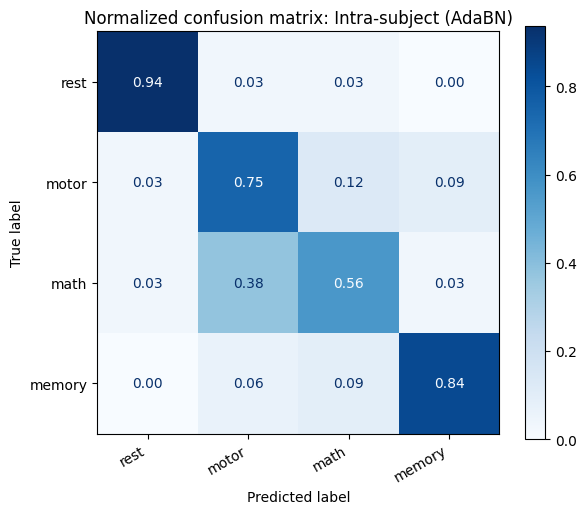

Saved: report_figures/confusion_matrix_cross_test1_adabn_normalized.png
Saved: report_figures/confusion_matrix_cross_test1_adabn_normalized.pdf


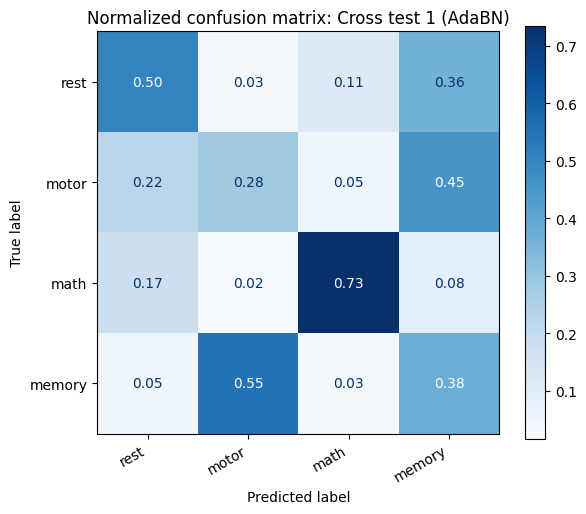

Saved: report_figures/confusion_matrix_cross_test2_adabn_normalized.png
Saved: report_figures/confusion_matrix_cross_test2_adabn_normalized.pdf


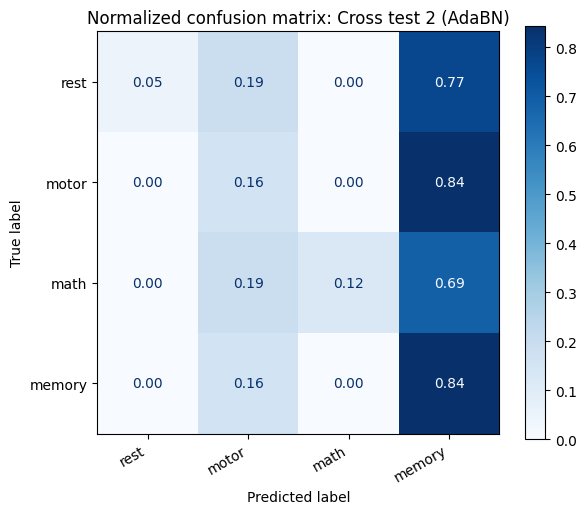

Saved: report_figures/confusion_matrix_cross_test3_adabn_normalized.png
Saved: report_figures/confusion_matrix_cross_test3_adabn_normalized.pdf


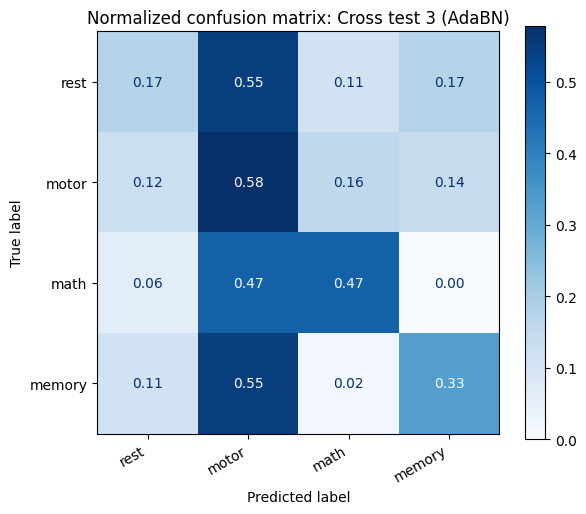

Saved: report_figures/confusion_matrix_intra_adabn_raw.png
Saved: report_figures/confusion_matrix_intra_adabn_raw.pdf


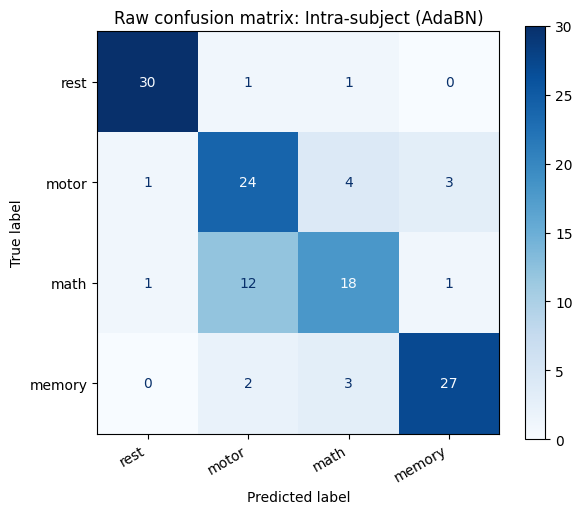

Saved: report_figures/confusion_matrix_cross_test1_adabn_raw.png
Saved: report_figures/confusion_matrix_cross_test1_adabn_raw.pdf


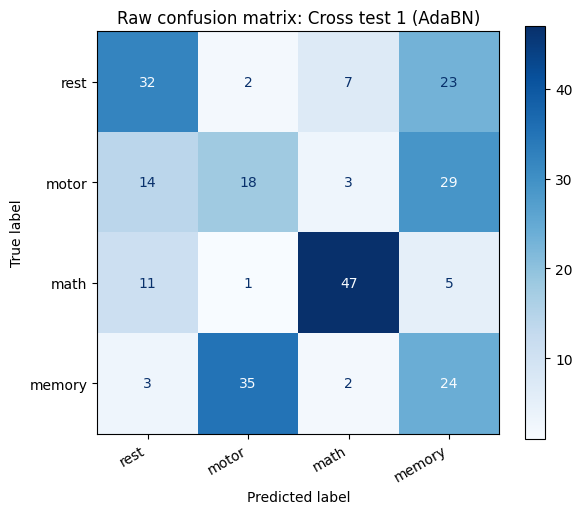

Saved: report_figures/confusion_matrix_cross_test2_adabn_raw.png
Saved: report_figures/confusion_matrix_cross_test2_adabn_raw.pdf


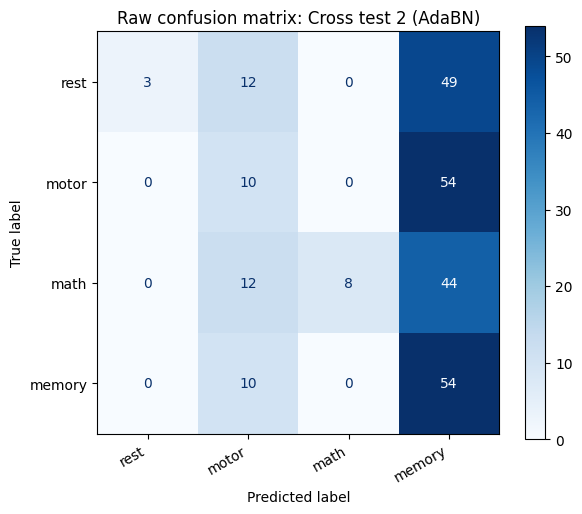

Saved: report_figures/confusion_matrix_cross_test3_adabn_raw.png
Saved: report_figures/confusion_matrix_cross_test3_adabn_raw.pdf


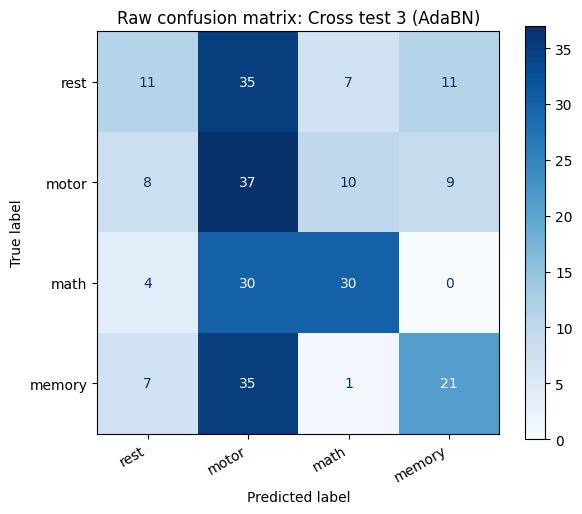

Saved: report_figures/combined_confusion_matrices_adabn.png
Saved: report_figures/combined_confusion_matrices_adabn.pdf


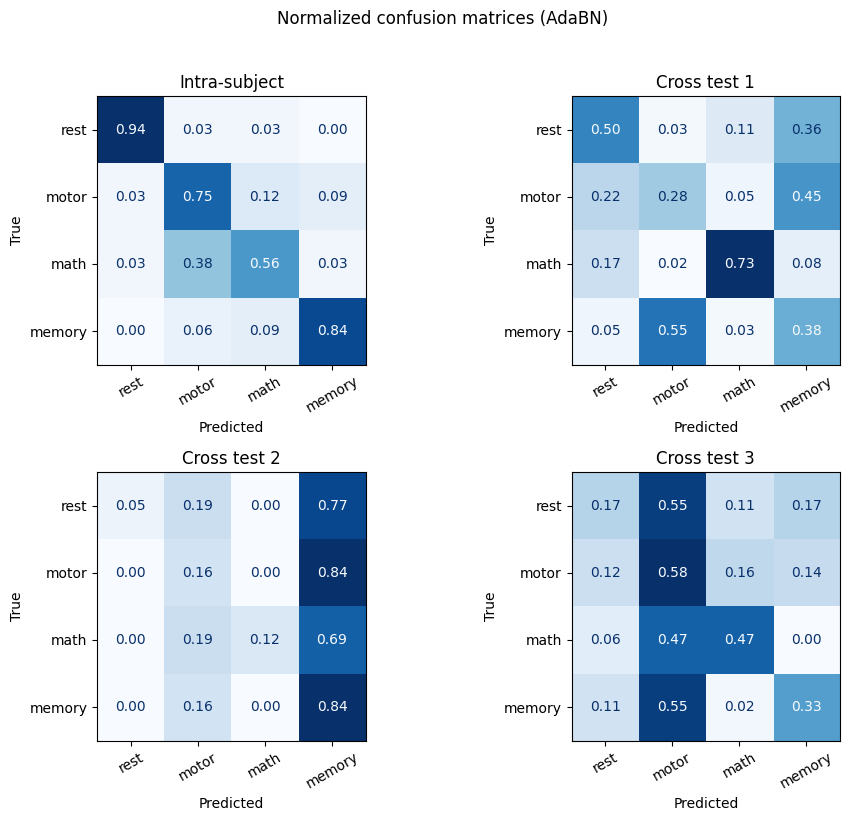

Saved: report_figures/accuracy_comparison_cv_test_shuffled.png
Saved: report_figures/accuracy_comparison_cv_test_shuffled.pdf


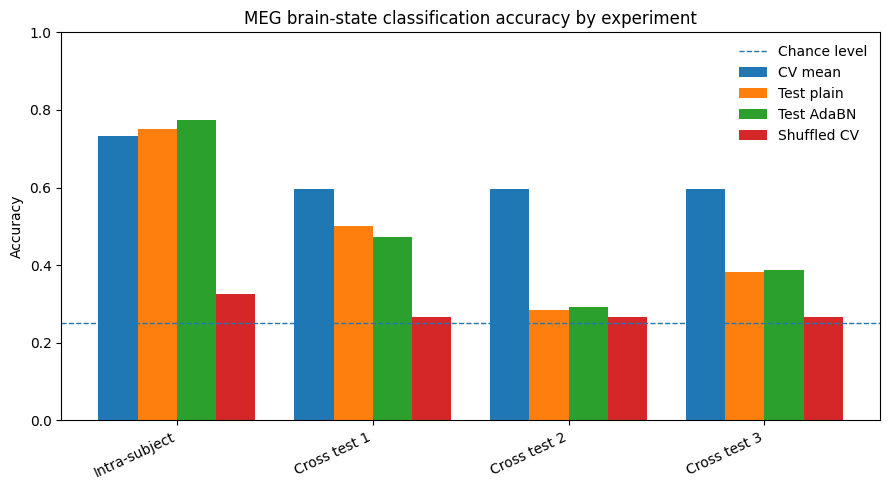

Saved: report_figures/class_metrics_intra_adabn.png
Saved: report_figures/class_metrics_intra_adabn.pdf


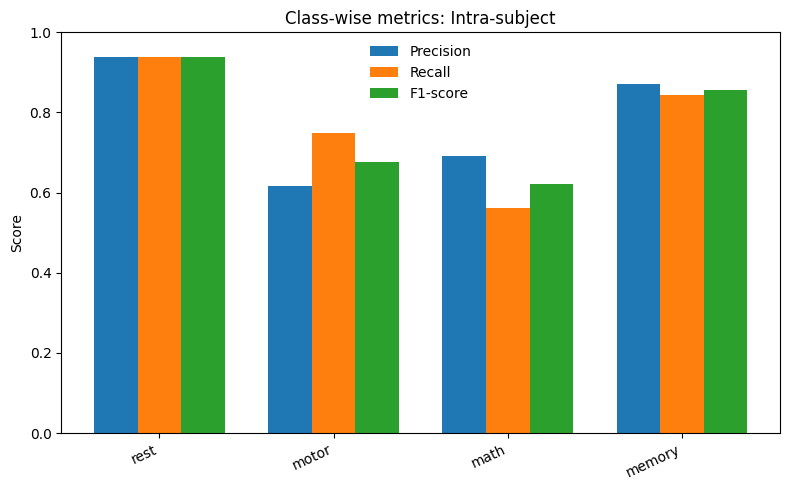

Saved: report_figures/class_metrics_cross_test1_adabn.png
Saved: report_figures/class_metrics_cross_test1_adabn.pdf


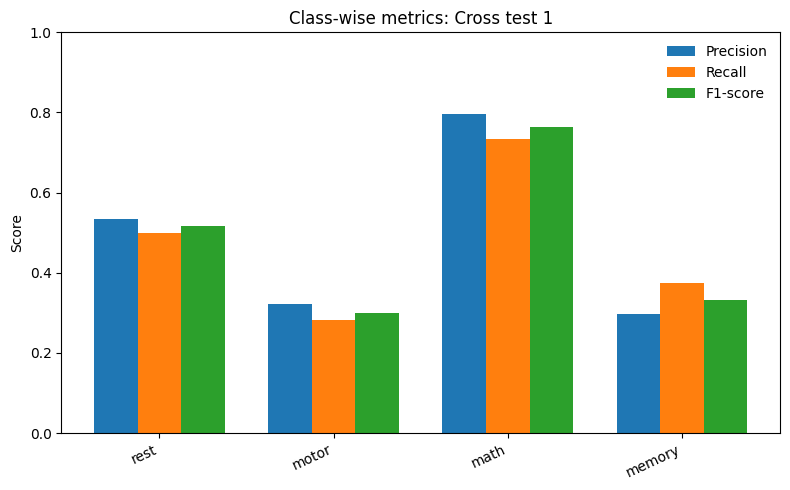

Saved: report_figures/class_metrics_cross_test2_adabn.png
Saved: report_figures/class_metrics_cross_test2_adabn.pdf


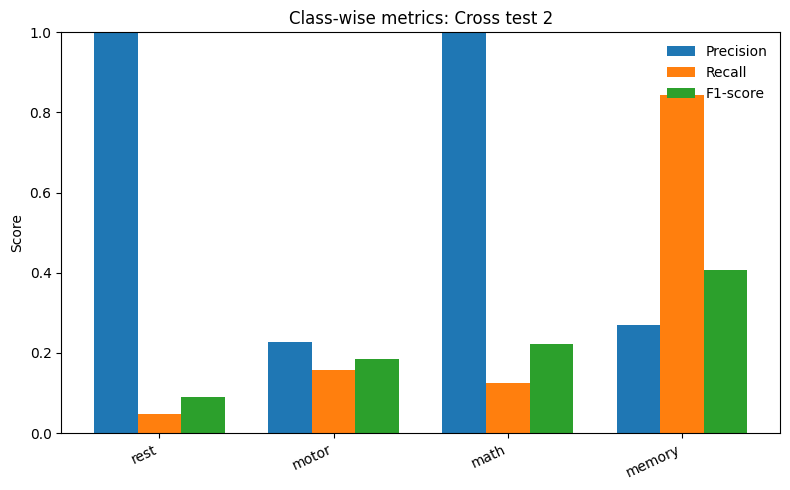

Saved: report_figures/class_metrics_cross_test3_adabn.png
Saved: report_figures/class_metrics_cross_test3_adabn.pdf


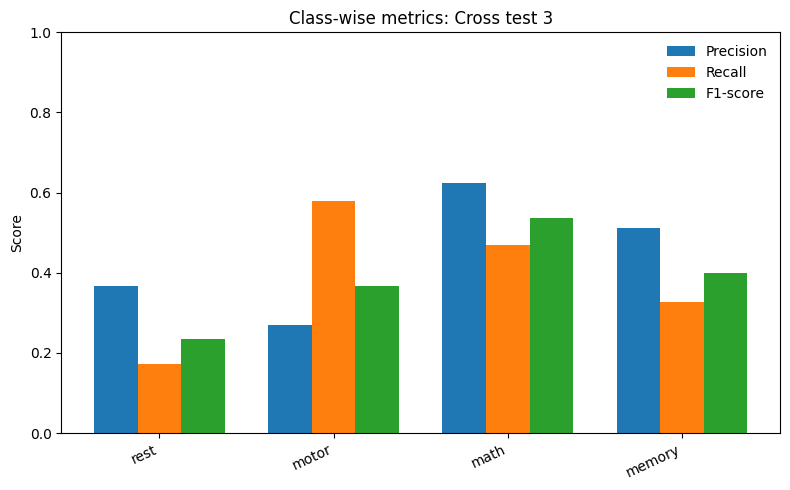

Saved: report_figures/class_metrics_adabn.csv
Saved: report_figures/learning_curve_intra.png
Saved: report_figures/learning_curve_intra.pdf


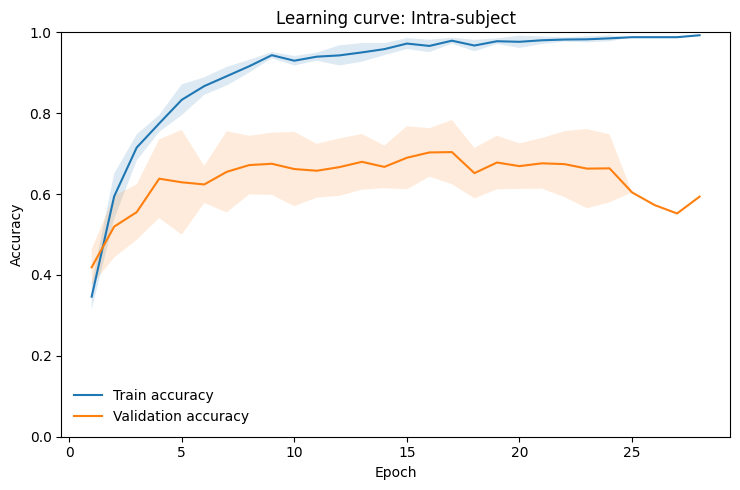

Saved: report_figures/learning_curve_cross_test1.png
Saved: report_figures/learning_curve_cross_test1.pdf


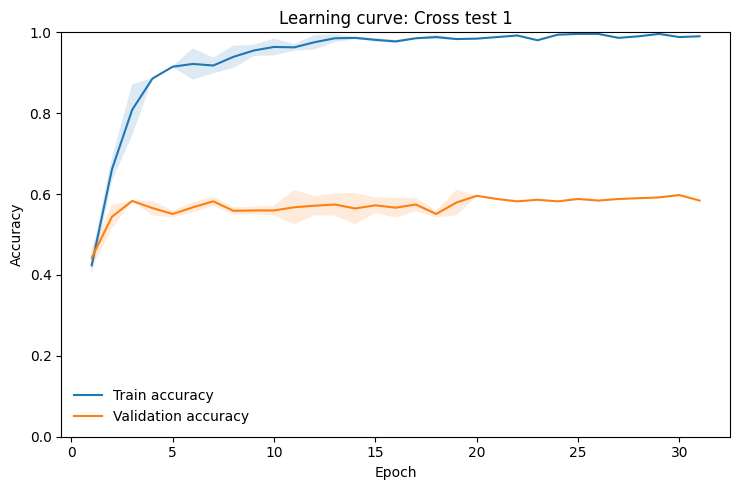

Saved: report_figures/learning_curve_cross_test2.png
Saved: report_figures/learning_curve_cross_test2.pdf


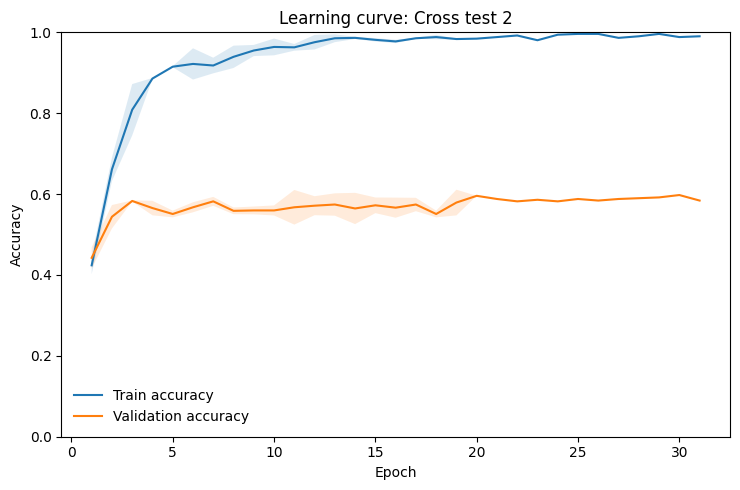

Saved: report_figures/learning_curve_cross_test3.png
Saved: report_figures/learning_curve_cross_test3.pdf


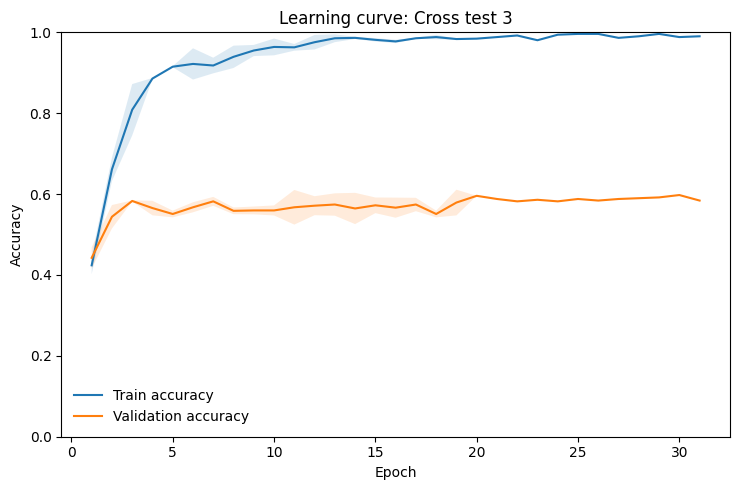

Saved: report_figures/loss_curve_intra.png
Saved: report_figures/loss_curve_intra.pdf


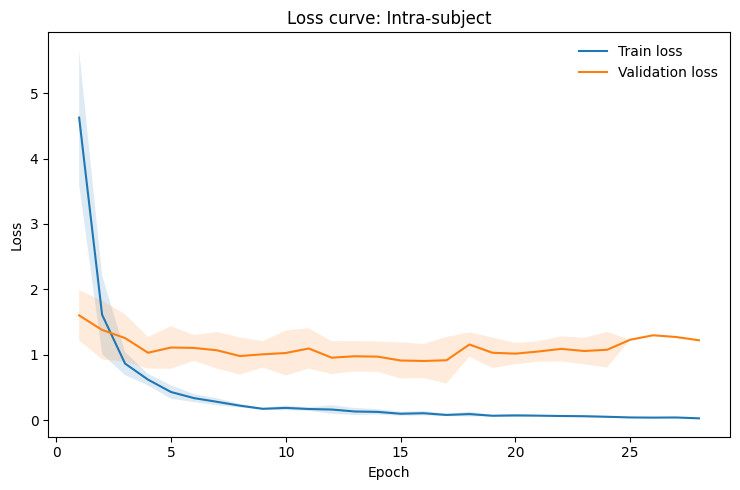

Saved: report_figures/loss_curve_cross_test1.png
Saved: report_figures/loss_curve_cross_test1.pdf


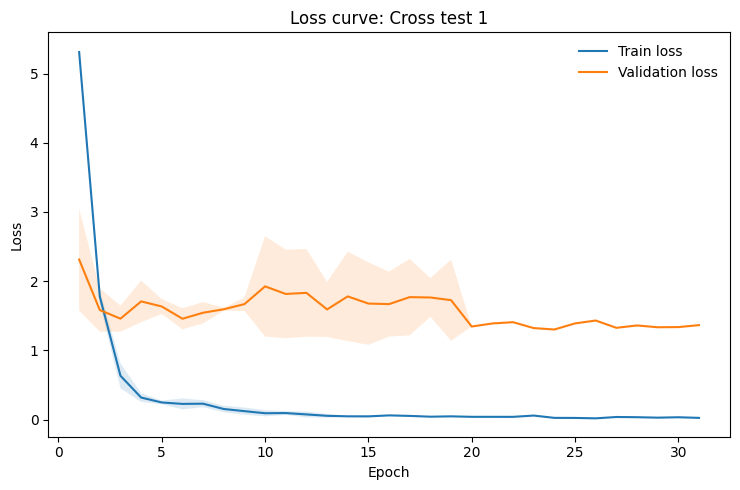

Saved: report_figures/loss_curve_cross_test2.png
Saved: report_figures/loss_curve_cross_test2.pdf


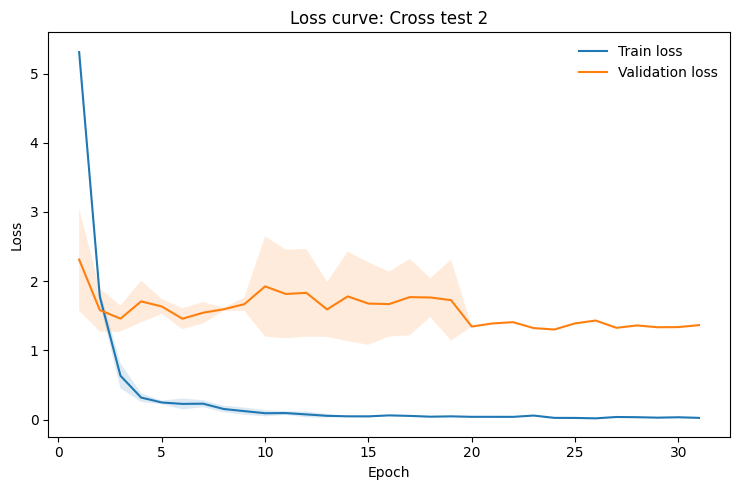

Saved: report_figures/loss_curve_cross_test3.png
Saved: report_figures/loss_curve_cross_test3.pdf


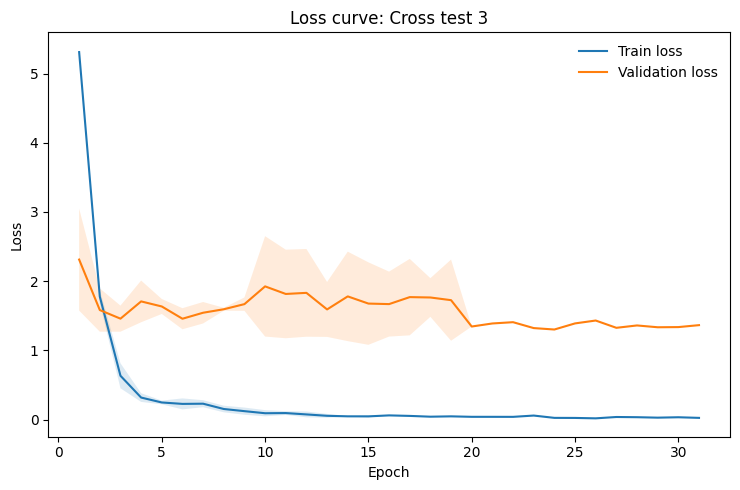

Saved: report_figures/confidence_distribution_intra_adabn.png
Saved: report_figures/confidence_distribution_intra_adabn.pdf


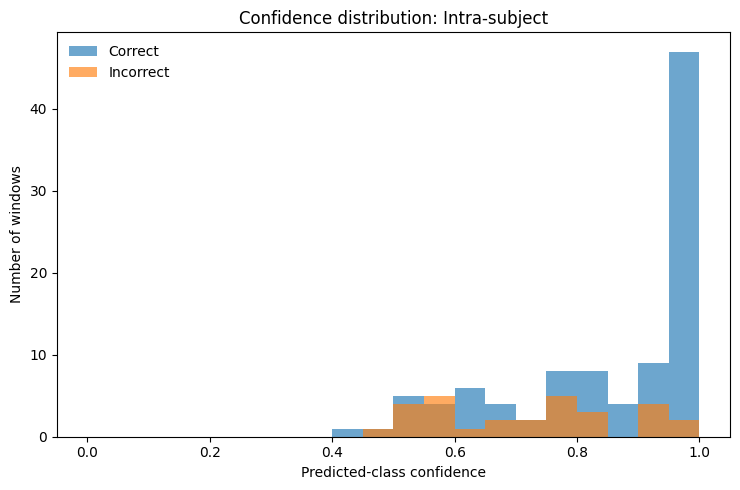

Saved: report_figures/confidence_distribution_cross_test1_adabn.png
Saved: report_figures/confidence_distribution_cross_test1_adabn.pdf


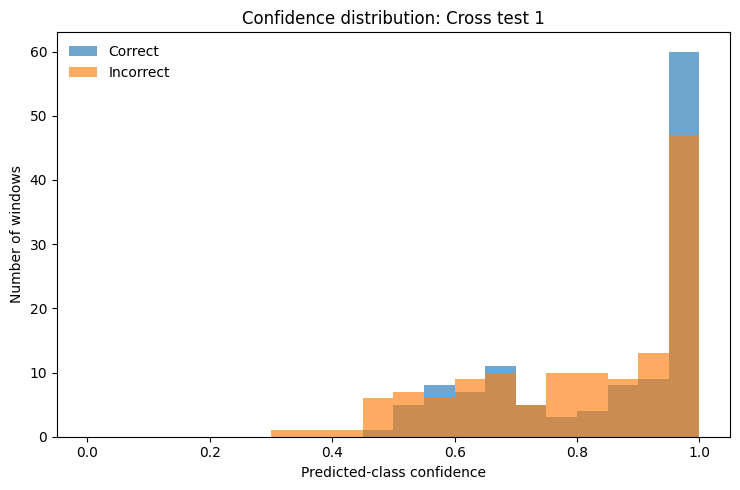

Saved: report_figures/confidence_distribution_cross_test2_adabn.png
Saved: report_figures/confidence_distribution_cross_test2_adabn.pdf


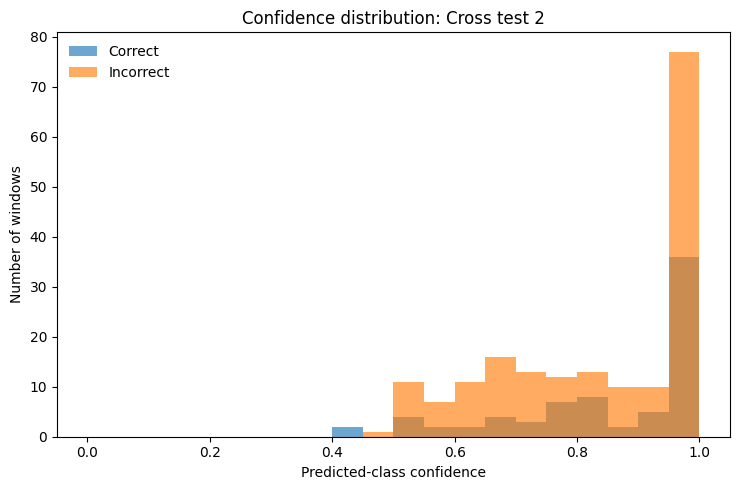

Saved: report_figures/confidence_distribution_cross_test3_adabn.png
Saved: report_figures/confidence_distribution_cross_test3_adabn.pdf


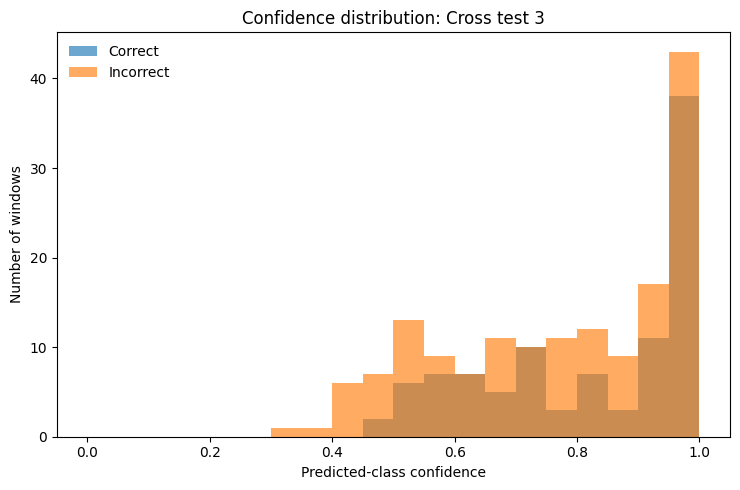

File not found: model_comparison_results.csv


In [4]:
#GENERATE GRAPHS
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
)

FIG_DIR = "report_figures"
os.makedirs(FIG_DIR, exist_ok=True)

CLASS_NAMES = [i2l[i] for i in range(N_CLASSES)]

# Cleaner labels for plots
EXP_LABELS = {
    "intra": "Intra-subject",
    "cross_test1": "Cross test 1",
    "cross_test2": "Cross test 2",
    "cross_test3": "Cross test 3",
}

def save_current_fig(filename):
    path_png = os.path.join(FIG_DIR, filename + ".png")
    path_pdf = os.path.join(FIG_DIR, filename + ".pdf")


    plt.savefig(path_png, dpi=300, bbox_inches="tight")
    plt.savefig(path_pdf, bbox_inches="tight")
    print(f"Saved: {path_png}")

    print(f"Saved: {path_pdf}")

def get_test_predictions(result, mode="adabn"):

    y_true = np.asarray(result["test_results"][mode]["prediction_df"]["true"])
    y_pred = np.asarray(result["test_results"][mode]["prediction_df"]["pred"])
    return y_true, y_pred

def get_exp_label(exp_key):
    return EXP_LABELS.get(exp_key, exp_key)
#CONFUSION MATRICES  Produces raw and normalized confusion matrices for each experiment.


def plot_confusion_for_experiment(exp_key, mode="adabn", normalize=None):

    result = all_results[exp_key]
    y_true, y_pred = get_test_predictions(result, mode=mode)

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(N_CLASSES)),
        normalize=normalize,
    )

    fig, ax = plt.subplots(figsize=(6.2, 5.2))


    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=CLASS_NAMES,
    )

    value_format = ".2f" if normalize else "d"
    disp.plot(
        ax=ax,

        cmap="Blues",
        values_format=value_format,
        colorbar=True,
    )

    mode_label = "AdaBN" if mode == "adabn" else "Plain"
    norm_label = "Normalized" if normalize else "Raw"

    ax.set_title(f"{norm_label} confusion matrix: {get_exp_label(exp_key)} ({mode_label})")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")


    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()

    suffix = "normalized" if normalize else "raw"
    save_current_fig(f"confusion_matrix_{exp_key}_{mode}_{suffix}")
    plt.show()


# Main report version: AdaBN, normalized
for exp_key in ["intra", "cross_test1", "cross_test2", "cross_test3"]:
    plot_confusion_for_experiment(exp_key, mode="adabn", normalize="true")


# Optional appendix version: raw counts

for exp_key in ["intra", "cross_test1", "cross_test2", "cross_test3"]:

    plot_confusion_for_experiment(exp_key, mode="adabn", normalize=None)

# COMBINED CONFUSION MATRIX PANEL Good for the main IEEE report because it saves space.



def plot_combined_confusion_panel(mode="adabn", normalize="true"):
    exp_keys = ["intra", "cross_test1", "cross_test2", "cross_test3"]

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    axes = axes.ravel()

    for ax, exp_key in zip(axes, exp_keys):
        result = all_results[exp_key]
        y_true, y_pred = get_test_predictions(result, mode=mode)

        cm = confusion_matrix(
            y_true,
            y_pred,
            labels=list(range(N_CLASSES)),
            normalize=normalize,
        )


        disp = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            display_labels=CLASS_NAMES,
        )


        disp.plot(
            ax=ax,
            cmap="Blues",
            values_format=".2f",

            colorbar=False,
        )

        ax.set_title(get_exp_label(exp_key))
        ax.set_xlabel("Predicted")

        ax.set_ylabel("True")
        ax.tick_params(axis="x", rotation=30)

    mode_label = "AdaBN" if mode == "adabn" else "Plain"
    fig.suptitle(f"Normalized confusion matrices ({mode_label})", y=1.02)

    plt.tight_layout()
    save_current_fig(f"combined_confusion_matrices_{mode}")
    plt.show()


plot_combined_confusion_panel(mode="adabn", normalize="true")

#FINAL ACCURACY COMPARISON Shows CV, plain test, AdaBN test, and shuffled-label control.


def plot_accuracy_comparison(final_results_df):
    df = final_results_df.copy()
    df["label"] = df["experiment"].map(lambda x: EXP_LABELS.get(x, x))

    x = np.arange(len(df))
    width = 0.20

    fig, ax = plt.subplots(figsize=(9, 5))


    ax.bar(x - 1.5 * width, df["cv_mean_acc"], width, label="CV mean")


    ax.bar(x - 0.5 * width, df["test_acc_plain"], width, label="Test plain")
    ax.bar(x + 0.5 * width, df["test_acc_adabn"], width, label="Test AdaBN")


    if "shuffled_cv_mean_acc" in df.columns:
        ax.bar(x + 1.5 * width, df["shuffled_cv_mean_acc"], width, label="Shuffled CV")

    ax.axhline(0.25, linestyle="--", linewidth=1, label="Chance level")

    ax.set_ylabel("Accuracy")

    ax.set_title("MEG brain-state classification accuracy by experiment")

    ax.set_xticks(x)


    ax.set_xticklabels(df["label"], rotation=25, ha="right")
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    plt.tight_layout()
    save_current_fig("accuracy_comparison_cv_test_shuffled")
    plt.show()


plot_accuracy_comparison(final_results_df)

#CLASS-WISE METRICS
# Produces one grouped bar plot per experiment.


def compute_class_metrics(exp_key, mode="adabn"):
    result = all_results[exp_key]
    y_true, y_pred = get_test_predictions(result, mode=mode)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=list(range(N_CLASSES)),
        zero_division=0,
    )

    return pd.DataFrame({
        "class_id": list(range(N_CLASSES)),
        "class_name": CLASS_NAMES,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "support": support,
        "experiment": exp_key,
        "mode": mode,
    })


def plot_class_metrics(exp_key, mode="adabn"):
    df = compute_class_metrics(exp_key, mode=mode)

    x = np.arange(len(df))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 5))



    ax.bar(x - width, df["precision"], width, label="Precision")
    ax.bar(x, df["recall"], width, label="Recall")


    ax.bar(x + width, df["f1"], width, label="F1-score")

    ax.set_ylabel("Score")
    ax.set_title(f"Class-wise metrics: {get_exp_label(exp_key)}")
    ax.set_xticks(x)


    ax.set_xticklabels(df["class_name"], rotation=25, ha="right")
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    plt.tight_layout()
    save_current_fig(f"class_metrics_{exp_key}_{mode}")
    plt.show()

    return df


all_metric_dfs = []

for exp_key in ["intra", "cross_test1", "cross_test2", "cross_test3"]:
    metric_df = plot_class_metrics(exp_key, mode="adabn")
    all_metric_dfs.append(metric_df)

class_metrics_df = pd.concat(all_metric_dfs, ignore_index=True)
class_metrics_df.to_csv(os.path.join(FIG_DIR, "class_metrics_adabn.csv"), index=False)

print("Saved:", os.path.join(FIG_DIR, "class_metrics_adabn.csv"))

# LEARNING CURVES

# Uses each result["history_df"] from all_results.

# Shows mean train/validation accuracy over CV folds.

def plot_learning_curve(exp_key):
    result = all_results[exp_key]
    hist = result["history_df"].copy()

    # Average over folds by epoch.
    grouped = hist.groupby("epoch").agg(
        train_acc_mean=("train_acc", "mean"),


        train_acc_std=("train_acc", "std"),


        val_acc_mean=("val_acc", "mean"),
        val_acc_std=("val_acc", "std"),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(7.5, 5))

    ax.plot(grouped["epoch"], grouped["train_acc_mean"], label="Train accuracy")
    ax.plot(grouped["epoch"], grouped["val_acc_mean"], label="Validation accuracy")

    ax.fill_between(
        grouped["epoch"],
        grouped["train_acc_mean"] - grouped["train_acc_std"].fillna(0),
        grouped["train_acc_mean"] + grouped["train_acc_std"].fillna(0),
        alpha=0.15,
    )

    ax.fill_between(
        grouped["epoch"],


        grouped["val_acc_mean"] - grouped["val_acc_std"].fillna(0),
        grouped["val_acc_mean"] + grouped["val_acc_std"].fillna(0),
        alpha=0.15,
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")



    ax.set_title(f"Learning curve: {get_exp_label(exp_key)}")
    ax.set_ylim(0, 1.0)
    ax.legend(frameon=False)

    plt.tight_layout()
    save_current_fig(f"learning_curve_{exp_key}")
    plt.show()


for exp_key in ["intra", "cross_test1", "cross_test2", "cross_test3"]:
    plot_learning_curve(exp_key)

# LOSS CURVES
# Useful for discussing overfitting/generalization gap.


def plot_loss_curve(exp_key):
    result = all_results[exp_key]
    hist = result["history_df"].copy()

    grouped = hist.groupby("epoch").agg(
        train_loss_mean=("train_loss", "mean"),


        train_loss_std=("train_loss", "std"),
        val_loss_mean=("val_loss", "mean"),
        val_loss_std=("val_loss", "std"),
    ).reset_index()

    fig, ax = plt.subplots(figsize=(7.5, 5))

    ax.plot(grouped["epoch"], grouped["train_loss_mean"], label="Train loss")
    ax.plot(grouped["epoch"], grouped["val_loss_mean"], label="Validation loss")

    ax.fill_between(
        grouped["epoch"],
        grouped["train_loss_mean"] - grouped["train_loss_std"].fillna(0),


        grouped["train_loss_mean"] + grouped["train_loss_std"].fillna(0),
        alpha=0.15,
    )

    ax.fill_between(
        grouped["epoch"],
        grouped["val_loss_mean"] - grouped["val_loss_std"].fillna(0),
        grouped["val_loss_mean"] + grouped["val_loss_std"].fillna(0),
        alpha=0.15,
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(f"Loss curve: {get_exp_label(exp_key)}")
    ax.legend(frameon=False)

    plt.tight_layout()
    save_current_fig(f"loss_curve_{exp_key}")
    plt.show()


for exp_key in ["intra", "cross_test1", "cross_test2", "cross_test3"]:
    plot_loss_curve(exp_key)


# Shows whether wrong predictions are low-confidence.


def plot_confidence_distribution(exp_key, mode="adabn"):
    result = all_results[exp_key]
    pred_df = result["test_results"][mode]["prediction_df"].copy()

    pred_df["correct"] = pred_df["true"] == pred_df["pred"]

    correct_conf = pred_df.loc[pred_df["correct"], "confidence"].to_numpy()


    wrong_conf = pred_df.loc[~pred_df["correct"], "confidence"].to_numpy()

    fig, ax = plt.subplots(figsize=(7.5, 5))

    bins = np.linspace(0, 1, 21)

    ax.hist(correct_conf, bins=bins, alpha=0.65, label="Correct")
    ax.hist(wrong_conf, bins=bins, alpha=0.65, label="Incorrect")

    ax.set_xlabel("Predicted-class confidence")
    ax.set_ylabel("Number of windows")
    ax.set_title(f"Confidence distribution: {get_exp_label(exp_key)}")
    ax.legend(frameon=False)

    plt.tight_layout()
    save_current_fig(f"confidence_distribution_{exp_key}_{mode}")
    plt.show()


for exp_key in ["intra", "cross_test1", "cross_test2", "cross_test3"]:
    plot_confidence_distribution(exp_key, mode="adabn")



EEGNET BASELINE

In [ ]:
#EEGNET CODE
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score

# temporal filters
# spatial filters per temporal filter
# pointwise filters (usually F1 * D)
# temporal kernel, odd so padding keeps length
# 0.5 is heavy regularization; try 0.25 if underfitting
# EEGNet trains well around 1e-3, unlike the bandpower CNN
EEG_F1 = 8
EEG_D = 2
EEG_F2 = 16
EEG_KERN_LENGTH = 125


EEG_DROPOUT = 0.5
EEG_LR = 1e-3
EEG_WEIGHT_DECAY = 1e-4


EEG_BATCH_SIZE = 64
EEG_PER_SAMPLE_NORM = True  # standardize each window by its own statistics

# In cell 1, the raw windows are already z scored, per channel, per recording. Optionally we standardize each window individually using its own statistics (robust and stateless) and add the channel axis required by EEGNet.
class EEGRawPreprocessor:
    def __init__(self, per_sample_norm=True, eps=1e-8):
        self.per_sample_norm = per_sample_norm
        self.eps = eps

    def fit(self, X):
        return self  # stateless

    def transform(self, X):
        X = ensure_samples_channels_time(X)  # (n, channels, time)


        if self.per_sample_norm:
            mean = X.mean(axis=(1, 2), keepdims=True)
            std = X.std(axis=(1, 2), keepdims=True)
            X = (X - mean) / (std + self.eps)
        return X[:, np.newaxis, :, :].astype(np.float32)  # (n, 1, channels, time)

#EEGNET MODEL
# Lawhern et al. 2018 Block 1 learns temporal (frequency) filters followed by depthwise spatial filters over the 248 channels. Block 2 : Separable # convolution. compact which suits the very small number of subjects.  The # original paper also uses max norm constraints on the depthwise and dense # layers; those are omitted here for simplicity.
class EEGNet(nn.Module):
    def __init__(self, n_classes, input_shape, F1=EEG_F1, D=EEG_D, F2=EEG_F2,
                 kern_length=EEG_KERN_LENGTH, p_drop=EEG_DROPOUT):
        super().__init__()
        _, n_channels, n_time = input_shape  # input_shape = (1, channels, time)



        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, kern_length), padding=(0, kern_length // 2), bias=False),
            nn.BatchNorm2d(F1),
        )

        #Depthwise spatial conv: one (channels, 1) filter group per temporal map.
        self.depthwise = nn.Sequential(


            nn.Conv2d(F1, F1 * D, (n_channels, 1), groups=F1, bias=False),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout(p_drop),
        )

        # Separable conv: depthwise temporal then pointwise mixing.
        self.separable = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, 16), padding=(0, 8), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),

            nn.Dropout(p_drop),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, *input_shape)
            flat_dim = self._features(dummy).flatten(1).shape[1]

        self.head = nn.Linear(flat_dim, n_classes)

    def _features(self, x):
        x = self.block1(x)
        x = self.depthwise(x)
        x = self.separable(x)
        return x

    def forward(self, x):
        x = self._features(x)
        x = x.flatten(1)
        return self.head(x)

# Generic runners (shared by any model + preprocessor pair)

def run_cv_generic(
    X_raw, y, groups, cv_strategy, run_name, max_epochs,
    make_preprocessor, make_model,
    lr, weight_decay, batch_size, save_artifacts=False,
):
    seed_all(SEED)

    X_raw = ensure_samples_channels_time(X_raw)
    y = np.asarray(y, dtype=np.int64)

    if groups is not None:
        groups = np.asarray(groups)
        if len(groups) != len(y):
            print("WARNING: groups length does not match y. Falling back to StratifiedKFold.")
            groups = None
            cv_strategy = "stratified"

    if cv_strategy == "loso" and groups is not None:
        splitter = LeaveOneGroupOut()

        split_iter = list(splitter.split(X_raw, y, groups))
        cv_type = "LeaveOneSubjectOut"
    elif cv_strategy == "group_kfold" and HAS_STRATIFIED_GROUP_KFOLD and groups is not None:


        splitter = StratifiedGroupKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

        split_iter = list(splitter.split(X_raw, y, groups))
        cv_type = "StratifiedGroupKFold"
    else:
        splitter = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
        split_iter = list(splitter.split(X_raw, y))
        cv_type = "StratifiedKFold"

    n_folds = len(split_iter)

    print("\n" + "=" * 80)
    print(f"RUNNING CV: {run_name}")
    print("CV type:", cv_type, "| folds:", n_folds)

    print("X_raw:", X_raw.shape, "| y:", y.shape)
    print("=" * 80)

    all_histories = []
    fold_summaries = []

    fold_artifacts = []

    for fold_id, (train_idx, val_idx) in enumerate(split_iter, start=1):
        print("\n" + "=" * 80)
        print(f"{run_name} | FOLD {fold_id}/{n_folds} ({cv_type})")
        print("=" * 80)

        seed_all(SEED + fold_id)

        X_raw_train = X_raw[train_idx]
        X_raw_val = X_raw[val_idx]
        y_train = y[train_idx]
        y_val = y[val_idx]

        preprocessor = make_preprocessor()


        preprocessor.fit(X_raw_train)
        X_train_map = preprocessor.transform(X_raw_train)
        X_val_map = preprocessor.transform(X_raw_val)

        input_shape = X_train_map.shape[1:]

        # print(input_shape)
        model = make_model(input_shape)

        class_weights = make_class_weights(y_train, N_CLASSES)
        train_loader, val_loader = make_loaders(
            X_train_map, y_train, X_val_map, y_val, batch_size=batch_size)

        model, history, best_val_acc, best_epoch = train_one_fold(
            model, train_loader, val_loader, class_weights,


            fold_id=fold_id, max_epochs=max_epochs,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            lr=lr, weight_decay=weight_decay, verbose=True,
        )

        val_loss, val_acc, y_true, y_pred = evaluate_model(model, val_loader)

        if save_artifacts:
            fold_artifacts.append({
                "fold": fold_id,
                "model": copy.deepcopy(model).cpu(),
                "preprocessor": preprocessor,
                "input_shape": input_shape,


                "best_epoch": int(best_epoch),
                "best_val_acc": float(best_val_acc),
                "final_loaded_val_acc": float(val_acc),
                "final_loaded_val_loss": float(val_loss),
                "cv_type": cv_type,
                "run_name": run_name,
            })

        fold_summaries.append({
            "run_name": run_name, "fold": fold_id,
            "best_epoch": best_epoch, "best_val_acc": best_val_acc,
            "final_loaded_val_acc": val_acc, "final_loaded_val_loss": val_loss,
            "n_train": len(train_idx), "n_val": len(val_idx),
            "params": count_params(model), "cv_type": cv_type,
            "lr": lr, "weight_decay": weight_decay, "batch_size": batch_size,
        })

        for r in history:
            r = dict(r)
            r["run_name"] = run_name
            r["cv_type"] = cv_type
            all_histories.append(r)

    history_df = pd.DataFrame(all_histories)
    summary_df = pd.DataFrame(fold_summaries)
    history_df.to_csv(f"{run_name}_history.csv", index=False)
    summary_df.to_csv(f"{run_name}_summary.csv", index=False)

    return history_df, summary_df, fold_artifacts


def train_final_ensemble_generic(
    X_train_raw, y_train, epoch_budget, n_models, run_name,
    make_preprocessor, make_model, lr, weight_decay, batch_size,
):
    X_train_raw = ensure_samples_channels_time(X_train_raw)
    y_train = np.asarray(y_train, dtype=np.int64)

    preprocessor = make_preprocessor()
    preprocessor.fit(X_train_raw)



    X_map = preprocessor.transform(X_train_raw)
    input_shape = X_map.shape[1:]
    class_weights = make_class_weights(y_train, N_CLASSES)

    print("\n" + "=" * 80)
    print(f"TRAINING FINAL ENSEMBLE: {run_name}")
    print("Models:", n_models, "| epoch budget:", epoch_budget, "| input:", input_shape)
    print("=" * 80)

    artifacts = []
    for m in range(n_models):
        seed_all(SEED + 100 + m)
        model = make_model(input_shape)


        train_loader = make_train_loader(X_map, y_train, batch_size=batch_size)
        model = train_no_val(
            model, train_loader, class_weights,
            n_epochs=epoch_budget, lr=lr, weight_decay=weight_decay,
            tag=f"{run_name}_m{m + 1}",
        )
        artifacts.append({
            "fold": m + 1,
            "model": copy.deepcopy(model).cpu(),
            "preprocessor": preprocessor,
            "input_shape": input_shape,
            "params": int(count_params(model)),
            "run_name": run_name,
        })
    return artifacts


def run_shuffled_control_generic(
    X_train, y_train, groups, cv_strategy, run_name,
    make_preprocessor, make_model, lr, weight_decay, batch_size,
):
    if not RUN_SHUFFLED_LABEL_CONTROL:
        return None, None

    rng = np.random.default_rng(SEED)
    y_shuffled = rng.permutation(np.asarray(y_train, dtype=np.int64))

    shuffled_history_df, shuffled_summary_df, _ = run_cv_generic(
        X_train, y_shuffled, groups, cv_strategy,
        run_name=f"{run_name}_shuffled_labels", max_epochs=SHUFFLED_CONTROL_EPOCHS,


        make_preprocessor=make_preprocessor, make_model=make_model,
        lr=lr, weight_decay=weight_decay, batch_size=batch_size, save_artifacts=False,
    )
    return shuffled_history_df, shuffled_summary_df


def run_full_experiment_generic(
    exp_key, make_preprocessor, make_model, lr, weight_decay, batch_size, tag,
):
    exp = experiments[exp_key]
    run_name = f"{tag}_{exp_key}"

    X_train = ensure_samples_channels_time(exp["X_train"])



    y_train = np.asarray(exp["y_train"], dtype=np.int64)
    X_test = ensure_samples_channels_time(exp["X_test"])


    y_test = np.asarray(exp["y_test"], dtype=np.int64)

    cv_groups, cv_strategy, n_subjects = choose_cv_strategy(exp)

    print("\n" + "#" * 80)
    print(f"STARTING EXPERIMENT: {run_name}")
    print("Name:", exp["name"])



    print("X_train:", X_train.shape, "| X_test:", X_test.shape)
    print("Training subjects:", n_subjects, "| CV strategy:", cv_strategy)
    print("#" * 80)

    # 1. Honest CV (validation only).
    cv_history_df, cv_summary_df, _ = run_cv_generic(
        X_train, y_train, cv_groups, cv_strategy, run_name, MAX_EPOCHS,
        make_preprocessor, make_model, lr, weight_decay, batch_size, save_artifacts=False,
    )

    # 2. Epoch budget from CV best epochs.
    best_epochs = cv_summary_df["best_epoch"].to_numpy()

    epoch_budget = max(MIN_FINAL_EPOCHS, int(round(float(np.median(best_epochs)))))
    print(f"\nEpoch budget for final ensemble: {epoch_budget} "
          f"(median CV best epoch over {len(best_epochs)} folds)")

    # 3. Refit ensemble on the full training set.
    fold_artifacts = train_final_ensemble_generic(
        X_train, y_train, epoch_budget, N_ENSEMBLE_MODELS, run_name,


        make_preprocessor, make_model, lr, weight_decay, batch_size,
    )

    # 4. External test via soft voting (reports both AdaBN modes).
    #    run_test_evaluation is defined in the corrected Cell 2 and is model
    #    agnostic, so EEGNet uses the exact same evaluator.
    test_results, primary_tag = run_test_evaluation(
        artifacts=fold_artifacts, X_test_raw=X_test, y_test=y_test, run_name=run_name,
    )

    # 5. Shuffled label control.
    shuffled_history_df, shuffled_summary_df = run_shuffled_control_generic(
        X_train, y_train, cv_groups, cv_strategy, run_name,
        make_preprocessor, make_model, lr, weight_decay, batch_size,
    )

    cv_vals = cv_summary_df["final_loaded_val_acc"].to_numpy()
    cv_mean = float(cv_vals.mean())

    cv_std = float(cv_vals.std(ddof=1)) if len(cv_vals) > 1 else 0.0


    test_acc_adabn = test_results.get("adabn", {}).get("acc", None)
    #print(test_acc_adabn)
    test_acc_plain = test_results.get("plain", {}).get("acc", None)
    # print()
    primary_test_acc = test_results[primary_tag]["acc"]

    result = {
        "exp_key": exp_key, "name": exp["name"],
        "train_folder": exp["train_folder"], "test_folder": exp["test_folder"],
        "cv_strategy": cv_strategy, "n_train_subjects": n_subjects,




        "cv_mean_acc": cv_mean, "cv_std_acc": cv_std,
        "test_acc_adabn": test_acc_adabn, "test_acc_plain": test_acc_plain,
        "primary_test_acc": float(primary_test_acc), "primary_tag": primary_tag,
        "epoch_budget": epoch_budget,

        "n_train_windows": int(len(y_train)), "n_test_windows": int(len(y_test)),
        "summary_df": cv_summary_df, "fold_artifacts": fold_artifacts,
        "test_results": test_results,
        "shuffled_summary_df": shuffled_summary_df,
    }
    if shuffled_summary_df is not None:
        result["shuffled_cv_mean_acc"] = float(shuffled_summary_df["final_loaded_val_acc"].mean())
    else:
        result["shuffled_cv_mean_acc"] = None
    return result


# Builders for EEGNet

def make_eeg_preprocessor():
    return EEGRawPreprocessor(per_sample_norm=EEG_PER_SAMPLE_NORM)


def make_eegnet(input_shape):
    return EEGNet(
        n_classes=N_CLASSES, input_shape=input_shape,
        F1=EEG_F1, D=EEG_D, F2=EEG_F2,
        kern_length=EEG_KERN_LENGTH, p_drop=EEG_DROPOUT,
    )

#  Run EEGNet on the required experiments

eeg_experiment_keys = ["intra", "cross_test1", "cross_test2", "cross_test3"]

all_results_eeg = {}
for exp_key in eeg_experiment_keys:
    all_results_eeg[exp_key] = run_full_experiment_generic(
        exp_key,


        make_preprocessor=make_eeg_preprocessor,
        make_model=make_eegnet,
        lr=EEG_LR, weight_decay=EEG_WEIGHT_DECAY, batch_size=EEG_BATCH_SIZE,
        tag="eegnet",
    )

#EEGNet results table

rows = []
for exp_key, result in all_results_eeg.items():
    rows.append({
        "experiment": exp_key, "name": result["name"],
        "cv_strategy": result["cv_strategy"], "n_train_subjects": result["n_train_subjects"],
        "cv_mean_acc": result["cv_mean_acc"], "cv_std_acc": result["cv_std_acc"],
        "test_acc_plain": result["test_acc_plain"],

        "test_acc_adabn": result["test_acc_adabn"],

        "primary_test_acc": result["primary_test_acc"],
        "shuffled_cv_mean_acc": result["shuffled_cv_mean_acc"],
    })

eegnet_results_df = pd.DataFrame(rows)

cross_keys = ["cross_test1", "cross_test2", "cross_test3"]
eeg_cross_avg = eegnet_results_df[
    eegnet_results_df["experiment"].isin(cross_keys)]["primary_test_acc"].mean()


       # print()
eeg_intra_acc = float(eegnet_results_df.loc[
    eegnet_results_df["experiment"] == "intra", "primary_test_acc"].iloc[0])

primary_label = "AdaBN (transductive)" if USE_ADABN else "plain (inductive)"

print("\n" + "=" * 80)
print("EEGNET RESULTS")
print("=" * 80)
print(eegnet_results_df.to_string(index=False))
print(f"\nPrimary reported metric: {primary_label}")


print("EEGNet intra subject test accuracy:", eeg_intra_acc)
print("EEGNet cross subject average test accuracy:", eeg_cross_avg)

eegnet_results_df.to_csv("eegnet_required_experiment_results.csv", index=False)
print("\nSaved: eegnet_required_experiment_results.csv")


#  Side by side comparison with the bandpower CNN (if available)

if "all_results" in globals():
    comp_rows = []
    for exp_key in eeg_experiment_keys:
        bp = all_results.get(exp_key, {})



        eg = all_results_eeg.get(exp_key, {})
        comp_rows.append({
            "experiment": exp_key,
            "bandpower_cnn_test_acc": bp.get("primary_test_acc", float("nan")),
            "eegnet_test_acc": eg.get("primary_test_acc", float("nan")),
        })
    comparison_df = pd.DataFrame(comp_rows)


    print("\n" + "=" * 80)
    print(f"BANDPOWER CNN vs EEGNET (primary test accuracy, {primary_label})")


    print("=" * 80)
    print(comparison_df.to_string(index=False))
    comparison_df.to_csv("model_comparison_results.csv", index=False)
    print("\nSaved: model_comparison_results.csv")


################################################################################
STARTING EXPERIMENT: eegnet_intra
Name: Intra subject
X_train: (512, 248, 1000) | X_test: (128, 248, 1000)
Training subjects: 1 | CV strategy: group_kfold
################################################################################

RUNNING CV: eegnet_intra
CV type: StratifiedGroupKFold | folds: 5
X_raw: (512, 248, 1000) | y: (512,)

eegnet_intra | FOLD 1/5 (StratifiedGroupKFold)
fold=1 epoch=001 train_loss=1.4400 train_acc=0.2476 val_loss=1.3963 val_acc=0.1875 best=0.1875@1 no_improve=0 lr=1.00e-03 time=28.4s
fold=1 epoch=002 train_loss=1.3837 train_acc=0.2764 val_loss=1.3964 val_acc=0.1875 best=0.1875@1 no_improve=1 lr=1.00e-03 time=21.1s
fold=1 epoch=003 train_loss=1.3610 train_acc=0.3101 val_loss=1.3965 val_acc=0.2500 best=0.2500@3 no_improve=0 lr=1.00e-03 time=21.3s
fold=1 epoch=004 train_loss=1.2928 train_acc=0.3654 val_loss=1.3909 val_acc=0.2812 best=0.2812@4 no_improve=0 lr=1.00e-03 time=21.5s